# E-Commerce Customer Profiles Analysis

## 1. Project Overview

### Business Needs

The company's business and marketing departments want to better understand their customers and their purchasing behavior. To achieve this, there is a need to identify and group customers based on specific demographic and behavioral parameters.

### Project Objective

The objective of this project is to create **Customer Profiles (CP)** based on defined demographic and behavioral parameters and to understand the characteristics and purchasing behavior of each profile.

### Analysis Scope

The analysis covers customer demographics, purchasing behavior, and customer value. It includes the creation and analysis of **Demographic Profiles** and **Behavioral Profiles**, as well as the examination of their combined characteristics.

---

## 2. Data Understanding

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")

df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [65]:
df.shape

(17049, 18)

In [66]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

In [67]:
df.duplicated().sum()

np.int64(0)

### Data Understanding Summary

- The dataset contains **17,049 rows and 18 columns**.
- There are **no duplicate rows**.
- There are **no missing values**.
- The dataset contains both **categorical and numerical variables**.
- The `Date` column contains date information and will be converted to **datetime format** during data preparation.

---

## 3. Data Cleaning & Preparation

In [68]:
df["Date"] = pd.to_datetime(df["Date"])

df["Date"].dtype

dtype('<M8[ns]')

In [69]:
df["Date"].head()

0   2023-05-29
1   2023-10-12
2   2023-12-05
3   2023-05-11
4   2023-06-16
Name: Date, dtype: datetime64[ns]

### Date Conversion

The `Date` column was converted to datetime format to ensure it can be used correctly in time-based analysis.

In [70]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 18, 24, 34, 44, 54, 75],
    labels=["-18", "19-24", "25-34", "35-44", "45-54", "55+"]
)

df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()

C:\Users\user\AppData\Local\Temp\ipykernel_19268\2293538970.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()


Age_Group
-18       453
19-24     545
25-34    1476
35-44    1521
45-54     769
55+       236
Name: Customer_ID, dtype: int64

### Age Group

The `Age` variable was grouped into defined age categories to facilitate demographic analysis.

The `18` age group represents customers aged **18 or below**.

In [71]:
df["Discount_Status"] = np.where(
    df["Discount_Amount"] > 0,
    "Discount Applied",
    "No Discount"
)

df["Discount_Status"].value_counts()

Discount_Status
No Discount         10572
Discount Applied     6477
Name: count, dtype: int64

### Discount Status

A `Discount_Status` variable was created to identify whether a discount was applied to each order.

---

## 4. Exploratory Data Analysis (EDA)

### Customer Demographics

#### Age Group

The distribution of customers across different age groups was examined to understand the demographic structure of the customer base.

In [72]:
df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()

C:\Users\user\AppData\Local\Temp\ipykernel_19268\890257737.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()


Age_Group
-18       453
19-24     545
25-34    1476
35-44    1521
45-54     769
55+       236
Name: Customer_ID, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_19268\3266095236.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()


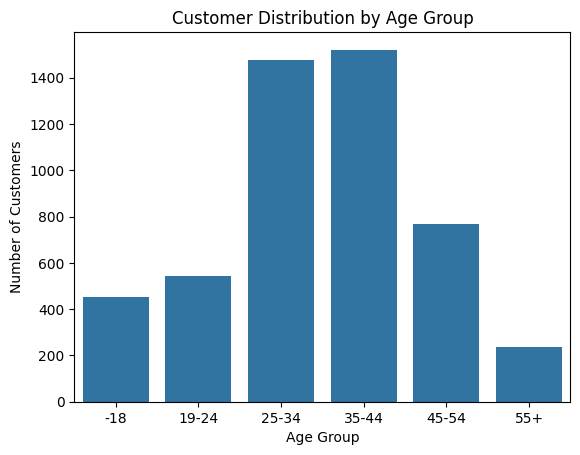

In [73]:
age_group_counts = df.groupby("Age_Group")["Customer_ID"].nunique().sort_index()

sns.barplot(x=age_group_counts.index, y=age_group_counts.values)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

#### Gender

The distribution of customers by gender was examined to understand the gender composition of the customer base.

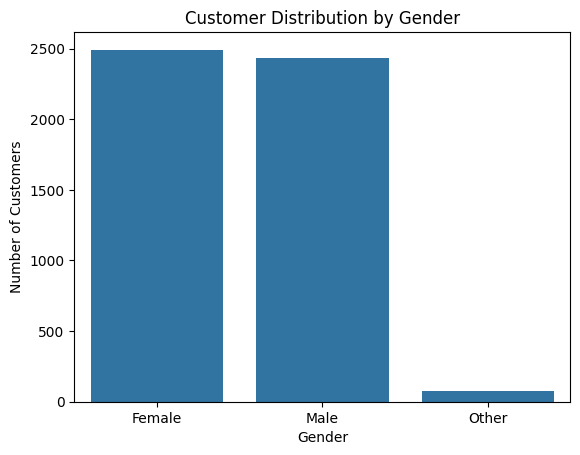

In [74]:
gender_counts = df.groupby("Gender")["Customer_ID"].nunique()

sns.barplot(x=gender_counts.index, y=gender_counts.values)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

#### City

The distribution of customers across cities was examined to understand the geographic composition of the customer base.

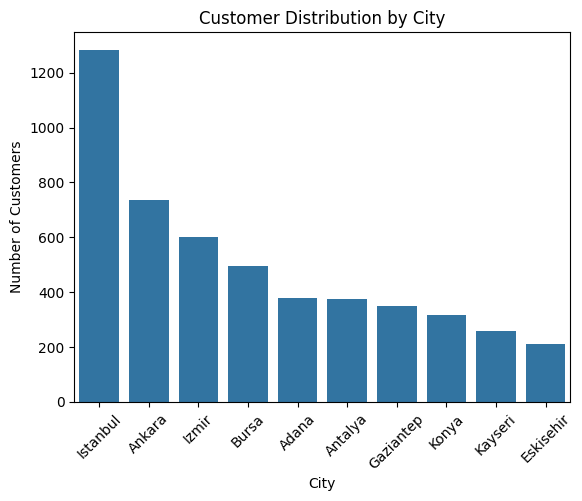

In [75]:
city_counts = df.groupby("City")["Customer_ID"].nunique().sort_values(ascending=False)

sns.barplot(x=city_counts.index, y=city_counts.values)

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Purchase & Product Information

#### Product Category

The distribution of customers across product categories was examined to understand their product preferences.

In [76]:
category_counts = (
    df.groupby("Product_Category")["Customer_ID"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Customer_Count")
)

category_counts

,Product_Category,Customer_Count
0,Books,1771
1,Sports,1767
2,Beauty,1753
3,Toys,1690
4,Food,1688
5,Electronics,1677
6,Fashion,1671
7,Home & Garden,1661


#### Quantity

The distribution of purchased quantities was examined to understand the typical number of units purchased per order.

In [77]:
quantity_counts = df["Quantity"].value_counts().sort_index()

quantity_counts

Quantity
1    3399
2    3358
3    3407
4    3420
5    3465
Name: count, dtype: int64

#### Unit Price & Total Amount

The distribution of unit prices and total amounts was examined to understand product pricing and order value in the dataset.

In [78]:
df[["Unit_Price", "Total_Amount"]].describe()

,Unit_Price,Total_Amount
count,17049.000000,17049.000000
mean,447.901689,1277.438711
std,722.319705,2358.436375
min,5.050000,6.210000
25%,73.260000,172.970000
50%,174.680000,455.850000
75%,494.570000,1267.750000
max,7900.010000,37852.050000


### Customer Behavior

#### Returning Customer

The distribution of returning and non-returning customers was examined to understand customer retention behavior.

In [79]:
df["Is_Returning_Customer"].value_counts()

Is_Returning_Customer
True     15039
False     2010
Name: count, dtype: int64

#### Discount Status

The distribution of orders with and without discounts was examined to understand the use of discounts in customer purchases.

In [80]:
df["Discount_Status"].value_counts()

Discount_Status
No Discount         10572
Discount Applied     6477
Name: count, dtype: int64

#### Session Duration & Pages Viewed

The distribution of session duration and pages viewed was examined to understand customer engagement and browsing behavior.

In [81]:
df[["Session_Duration_Minutes", "Pages_Viewed"]].describe()

,Session_Duration_Minutes,Pages_Viewed
count,17049.000000,17049.000000
mean,14.535633,9.003109
std,2.925524,2.259954
min,4.000000,1.000000
25%,13.000000,7.000000
50%,15.000000,9.000000
75%,17.000000,11.000000
max,26.000000,18.000000


### Customer Experience

#### Customer Rating & Delivery Time

The distribution of customer ratings and delivery times was examined to understand customer satisfaction and delivery performance.

In [82]:
df["Customer_Rating"].value_counts().sort_index()

Customer_Rating
1     781
2    1487
3    2658
4    5863
5    6260
Name: count, dtype: int64

In [83]:
df["Delivery_Time_Days"].value_counts().sort_index()

Delivery_Time_Days
1      233
2     1114
3     1985
4     2241
5     2231
6     2063
7     1686
8     1354
9     1095
10     800
11     733
12     524
13     302
14     213
15     157
16      72
17      73
18      56
19      28
20      35
21      12
22      13
23      11
24      10
25       8
Name: count, dtype: int64


---

## 5. Analysis

The Analysis section consists of four main stages:

- **Pre-Analysis** — The key variables that will be used in the following analyses are examined in advance to understand their distributions, relationships, and how they can be used in customer profiling.

- **Demographic Profile Analysis** — Customers are grouped into Demographic Profiles based on selected demographic characteristics. The profiles are then compared in terms of purchasing behavior, customer value, and revenue contribution.

- **Behavioral Profile Analysis** — Customers are grouped into Behavioral Profiles based on selected behavioral characteristics, including purchasing frequency, browsing engagement, returning behavior, discount usage, and purchase quantity. The resulting profiles are analyzed based on their characteristics and customer value.

- **Demographic & Behavioral Profile Analysis** — Demographic and Behavioral Profiles are analyzed together to examine the distribution, customer value, and purchasing patterns of customers across different profile combinations.

### 5.1 Pre-Analysis

#### Returning Customer 

**Question:** How do customers differ based on their returning behavior?

Customer-level returning behavior was examined by grouping customers according to their returning-customer history.

In [84]:
customer_status_2 = df.groupby("Customer_ID")["Is_Returning_Customer"].sum()

only_false_customers = customer_status_2[customer_status_2 == 0]

print(only_false_customers)
print("Number of customers with only False:", len(only_false_customers))
print("Total number of customers:", len(customer_status_2))

Customer_ID
CUST_00004    0
CUST_00009    0
CUST_00012    0
CUST_00037    0
CUST_00081    0
             ..
CUST_04966    0
CUST_04987    0
CUST_04988    0
CUST_04998    0
CUST_04999    0
Name: Is_Returning_Customer, Length: 349, dtype: int64
Number of customers with only False: 349
Total number of customers: 5000


In [85]:
customer_status_2 = df.groupby("Customer_ID")["Is_Returning_Customer"].agg(["any", "all"])

only_false = customer_status_2[
    (customer_status_2["any"] == False)
]

false_to_true = customer_status_2[
    (customer_status_2["any"] == True) &
    (customer_status_2["all"] == False)
]

only_true = customer_status_2[
    (customer_status_2["all"] == True)
]

any_true = customer_status_2[
    (customer_status_2["any"] == True)
]

print("Only False:", len(only_false))
print("False → True:", len(false_to_true))
print("Only True:", len(only_true))
print("Any True:", len(any_true))

Only False: 349
False → True: 1661
Only True: 2990
Any True: 4651


- **New Customers** → `Only False` — 349
- **Short-Term Returning** → `False → True` — 1,661
- **Long-Term Returning** → `Only True` — 2,990

`Any True` is not a separate profile; it represents the total number of **Short-Term Returning + Long-Term Returning = 4,651** customers.

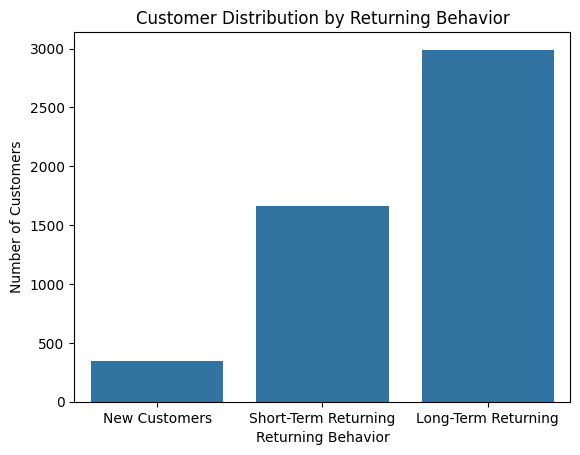

In [86]:
returning_counts = {
    "New Customers": len(only_false),
    "Short-Term Returning": len(false_to_true),
    "Long-Term Returning": len(only_true)
}

sns.barplot(
    x=list(returning_counts.keys()),
    y=list(returning_counts.values())
)

plt.title("Customer Distribution by Returning Behavior")
plt.xlabel("Returning Behavior")
plt.ylabel("Number of Customers")
plt.show()

**Question:** Do returning customers have a higher Average Order Value (AOV) than new customers?

In [87]:
false_customers = only_false.index
true_customers = any_true.index

false_group = df[df["Customer_ID"].isin(false_customers)]
true_group = df[df["Customer_ID"].isin(true_customers)]

false_aov = false_group.groupby("Order_ID")["Total_Amount"].sum().mean()
true_aov = true_group.groupby("Order_ID")["Total_Amount"].sum().mean()

print("AOV of New Customers:", false_aov)
print("AOV of Returning Customers:", true_aov)

AOV of New Customers: 1148.3400859598853
AOV of Returning Customers: 1280.1366407185628


Returning customers have a higher AOV (**1280.14**) compared to New Customers (**1148.34**), which is approximately **11.47% higher**.


**Question 1:** Do returning customers use discounts more frequently than new customers?

**Question 2:** Do returning customers receive a higher average discount amount than new customers?

In [88]:
false_discount_rate = (false_group["Discount_Amount"] > 0).mean() * 100

true_discount_rate = (true_group["Discount_Amount"] > 0).mean() * 100

print("Discount usage rate of New Customers:", false_discount_rate)
print("Discount usage rate of Returning Customers:", true_discount_rate)

Discount usage rate of New Customers: 33.2378223495702
Discount usage rate of Returning Customers: 38.08982035928143


In [89]:
false_avg_discount = (
    false_group[false_group["Discount_Amount"] > 0]["Discount_Amount"].mean()
)

true_avg_discount = (
    true_group[true_group["Discount_Amount"] > 0]["Discount_Amount"].mean()
)

print("Average discount amount of New Customers:", false_avg_discount)
print("Average discount amount of Returning Customers:", true_avg_discount)

Average discount amount of New Customers: 148.43413793103448
Average discount amount of Returning Customers: 184.34201540638264


Returning customers use discounts more than new customers, with a discount usage rate of **38.09%**, compared with **33.24%** for new customers. In addition, the average discount amount among discounted orders is higher for returning customers (**184.34**) than for new customers (**148.43**).

These results indicate that returning customers are both more likely to use discounts and receive higher average discount amounts when discounts are applied.


#### Customer Rating & Returning Behavior

**Question:** Is the rating given by customers who later returned higher than the rating given by customers who never returned?


In [90]:
false_to_true_customers = false_to_true.index

false_to_true_group = df[df["Customer_ID"].isin(false_to_true_customers)]

false_cust_rate = false_group["Customer_Rating"].mean()

false_to_true_cust_rate = false_to_true_group[
    false_to_true_group["Is_Returning_Customer"] == False
]["Customer_Rating"].mean()

print("Customer rating of New Customers:", false_cust_rate)
print("Customer rating of Short-Term Returning Customers:", false_to_true_cust_rate)

Customer rating of New Customers: 3.945558739255014
Customer rating of Short-Term Returning Customers: 3.863335340156532


### Demographic Values

The key demographic variables are examined to understand differences in purchasing behavior and customer value across demographic groups.

#### Gender

**Question:** How do customer value differ by gender?

In [91]:
gender_analysis = df.groupby("Gender").agg(
    order_n=("Order_ID", "count"),
    total_a=("Total_Amount", "sum"),
    avrg_a=("Total_Amount", "mean")
)

gender_analysis


,order_n,total_a,avrg_a
Gender,,,
Female,8613,11037984.60,1281.549356
Male,8176,10343185.70,1265.066744
Other,260,397882.29,1530.316500


#### Product Category & Gender

**Question:** How does customer value differ across product categories by gender?

In [92]:
gender_category_analysis = df.groupby(
    ["Product_Category", "Gender"]
).agg(
    order_n=("Order_ID", "count"),
    total_a=("Total_Amount", "sum"),
    avrg_a=("Total_Amount", "mean")
)

gender_category_analysis

order_n     total_a       avrg_a
Product_Category Gender                                  
Beauty           Female     1102   341442.59   309.839011
                 Male       1083   344659.47   318.245125
                 Other        27     8334.96   308.702222
Books            Female     1103   180434.35   163.585086
                 Male       1062   173074.11   162.969972
                 Other        41     6890.65   168.064634
Electronics      Female     1034  5214505.51  5043.042079
                 Male       1008  5053938.23  5013.827609
                 Other        32   213453.91  6670.434688
Fashion          Female     1039   811866.59   781.392291
                 Male        983   744393.82   757.267365
                 Other        34    20775.29   611.037941
Food             Female     1078   217725.97   201.972143
                 Male       1002   198846.13   198.449232
                 Other        23     5482.55   238.371739
Home & Garden    Female     1064  2091887.73  1966.059897
                 Male        967  1872271.91  1936.165367
                 Other        29    59744.30  2060.148276
Sports           Female     1134  1644781.57  1450.424665
                 Male       1069  1492620.41  1396.277278
                 Other        45    67685.01  1504.111333
Toys             Female     1059   535340.29   505.514910
                 Male       1002   463381.62   462.456707
                 Other        29    15515.62   535.021379

#### Age Group & Gender

**Question:** How does customer value differ across age groups by gender?

In [93]:
age_gender_analysis = df.groupby(
    ["Age_Group", "Gender"]
).agg(
    order_n=("Order_ID", "count"),
    total_a=("Total_Amount", "sum"),
    avrg_a=("Total_Amount", "mean")
)

age_gender_analysis

C:\Users\user\AppData\Local\Temp\ipykernel_19268\2924343065.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_analysis = df.groupby(


order_n     total_a       avrg_a
Age_Group Gender                                  
-18       Female      913  1109625.34  1215.361818
          Male        652   901654.05  1382.904985
          Other        40    73657.09  1841.427250
19-24     Female      898  1280307.39  1425.732060
          Male        871  1083172.88  1243.596877
          Other        25    14449.40   577.976000
25-34     Female     2520  3043069.18  1207.567135
          Male       2457  3156314.27  1284.621193
          Other        83   115885.23  1396.207590
35-44     Female     2514  3431496.08  1364.954686
          Male       2573  3196148.58  1242.187555
          Other        74   144315.54  1950.210000
45-54     Female     1344  1665279.93  1239.047567
          Male       1282  1611400.39  1256.942582
          Other        32    46522.96  1453.842500
55+       Female      424   508206.68  1198.600660
          Male        341   394495.53  1156.878387
          Other         6     3052.07   508.678333


---

### 5.2 Demographic Profile Analysis

Demographic Profiles are created to group customers based on their demographic characteristics and to examine differences in customer value and purchasing behavior across these groups.

#### Demographic Profile Creation

Customers are grouped into Demographic Profiles based on their: 
* age group,
* gender.

In [94]:
def create_demographic_profile(row):
    if row["Age_Group"] == "-18" and row["Gender"] == "Female":
        return "D 1"
    elif row["Age_Group"] == "-18" and row["Gender"] == "Male":
        return "D 2"
    elif row["Age_Group"] == "19-24" and row["Gender"] == "Female":
        return "D 3"
    elif row["Age_Group"] == "19-24" and row["Gender"] == "Male":
        return "D 4"
    elif row["Age_Group"] == "25-34" and row["Gender"] == "Female":
        return "D 5"
    elif row["Age_Group"] == "25-34" and row["Gender"] == "Male":
        return "D 6"
    elif row["Age_Group"] == "35-44" and row["Gender"] == "Female":
        return "D 7"
    elif row["Age_Group"] == "35-44" and row["Gender"] == "Male":
        return "D 8"
    elif row["Age_Group"] == "45-54" and row["Gender"] == "Female":
        return "D 9"
    elif row["Age_Group"] == "45-54" and row["Gender"] == "Male":
        return "D 10"
    elif row["Age_Group"] == "55+" and row["Gender"] == "Female":
        return "D 11"
    elif row["Age_Group"] == "55+" and row["Gender"] == "Male":
        return "D 12"
    else:
        return "Others"


df["Demographic_Profile"] = df.apply(create_demographic_profile, axis=1)

In [95]:
profile_counts = df.groupby("Demographic_Profile")["Customer_ID"].nunique()

profile_counts = profile_counts.reindex([
    "D 1", "D 2", "D 3", "D 4",
    "D 5", "D 6", "D 7", "D 8",
    "D 9", "D 10", "D 11", "D 12",
    "Others"
])

profile_counts

Demographic_Profile
D 1       245
D 2       199
D 3       272
D 4       267
D 5       731
D 6       720
D 7       738
D 8       758
D 9       378
D 10      385
D 11      128
D 12      106
Others     73
Name: Customer_ID, dtype: int64

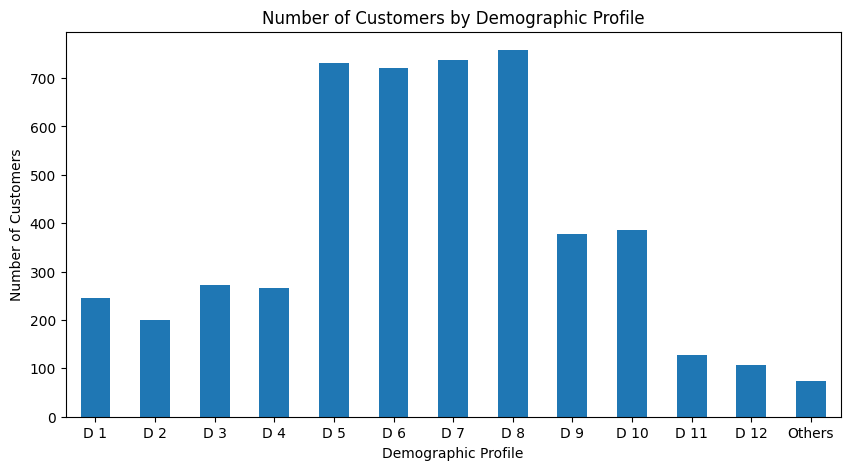

In [96]:
profile_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Number of Customers by Demographic Profile"
)

plt.xlabel("Demographic Profile")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The demographic profile distribution shows that customer concentration is highest among the **D 5, D 6, D 7, and D 8** profiles, with each profile containing more than 700 customers. These profiles represent customers aged **25–44**, indicating that this age range forms the largest part of the customer base across both Female and Male customers.

The **D 9 and D 10** profiles, representing customers aged **45–54**, have a moderate number of customers, while the **D 11 and D 12** profiles, representing customers aged **55+**, have considerably fewer customers.

The **Others** group contains 73 customers, representing a relatively small portion of the total customer base.

Overall, the customer base is concentrated primarily in the **25–44 age range**, while customers aged **55+** represent a smaller segment of the customer base.


#### Demographic Profile  Performance Ranking

Demographic Profiles are compared based on selected **economic indicators** that reflect their contribution and value. Each profile is then evaluated using a **star-based scoring system**, where the performance of the profiles across these indicators determines the number of stars assigned to each profile.

In [97]:
# Customer Count

profile_counts = (
    df.groupby("Demographic_Profile")["Customer_ID"]
    .nunique()
    .sort_values(ascending=False)
)

profile_counts

Demographic_Profile
D 8       758
D 7       738
D 5       731
D 6       720
D 10      385
D 9       378
D 3       272
D 4       267
D 1       245
D 2       199
D 11      128
D 12      106
Others     73
Name: Customer_ID, dtype: int64

In [98]:
# Top 3 Demographic Profiles by Customer Count

top_3_customer_count = profile_counts.sort_values(ascending=False).head(3)

top_3_customer_count.index = [
    f"{profile} ★★★" if i == 0 else
    f"{profile} ★★" if i == 1 else
    f"{profile} ★"
    for i, profile in enumerate(top_3_customer_count.index)
]

top_3_customer_count

D 8 ★★★    758
D 7 ★★     738
D 5 ★      731
Name: Customer_ID, dtype: int64

In [99]:
# Top 3 Demographic Profiles by Total Order Count

order_count = df.groupby("Demographic_Profile")["Order_ID"].nunique()

top_3_total_order_count = order_count.sort_values(ascending=False).head(3)

top_3_total_order_count.index = [
    f"{profile} ★★★" if i == 0 else
    f"{profile} ★★" if i == 1 else
    f"{profile} ★"
    for i, profile in enumerate(top_3_total_order_count.index)
]

top_3_total_order_count

D 8 ★★★    2573
D 5 ★★     2520
D 7 ★      2514
Name: Order_ID, dtype: int64

In [100]:
# Top 3 Demographic Profiles by Order Count per Customer

customer_count = df.groupby("Demographic_Profile")["Customer_ID"].nunique()

order_count_per_customer = order_count / customer_count

top_3_order_count_per_customer = (
    order_count_per_customer
    .sort_values(ascending=False)
    .head(3)
)

top_3_order_count_per_customer.index = [
    f"{profile} ★★★" if i == 0 else
    f"{profile} ★★" if i == 1 else
    f"{profile} ★"
    for i, profile in enumerate(top_3_order_count_per_customer.index)
]

top_3_order_count_per_customer

D 1 ★★★      3.726531
Others ★★    3.561644
D 9 ★        3.555556
dtype: float64

In [101]:
# Top 3 Demographic Profiles by Total Amount

total_amount = df.groupby("Demographic_Profile")["Total_Amount"].sum()

top_3_total_amount = total_amount.sort_values(ascending=False).head(3)

top_3_total_amount.index = [
    f"{profile} ★★★" if i == 0 else
    f"{profile} ★★" if i == 1 else
    f"{profile} ★"
    for i, profile in enumerate(top_3_total_amount.index)
]

top_3_total_amount

D 7 ★★★    3431496.08
D 8 ★★     3196148.58
D 6 ★      3156314.27
Name: Total_Amount, dtype: float64

In [102]:
# Top 3 Demographic Profiles by Average Amount per Customer

customer_count = df.groupby("Demographic_Profile")["Customer_ID"].nunique()

average_amount_per_customer = total_amount / customer_count

top_3_average_amount_per_customer = (
    average_amount_per_customer
    .sort_values(ascending=False)
    .head(3)
)

top_3_average_amount_per_customer.index = [
    f"{profile} ★★★" if i == 0 else
    f"{profile} ★★" if i == 1 else
    f"{profile} ★"
    for i, profile in enumerate(top_3_average_amount_per_customer.index)
]

top_3_average_amount_per_customer

Others ★★★    5450.442329
D 3 ★★        4707.012463
D 7 ★         4649.723686
dtype: float64

In [103]:
# Customer Count
top_3_customer_count = (
    profile_counts
    .sort_values(ascending=False)
    .head(3)
)

# Total Order Count
top_3_total_order_count = (
    order_count
    .sort_values(ascending=False)
    .head(3)
)

# Order Count per Customer
top_3_order_count_per_customer = (
    order_count_per_customer
    .sort_values(ascending=False)
    .head(3)
)

# Total Amount
top_3_total_amount = (
    total_amount
    .sort_values(ascending=False)
    .head(3)
)

# Average Amount per Customer
top_3_average_amount_per_customer = (
    average_amount_per_customer
    .sort_values(ascending=False)
    .head(3)
)


# Ulduzları toplamaq
star_score = {}

top_3_lists = [
    top_3_customer_count,
    top_3_total_order_count,
    top_3_order_count_per_customer,
    top_3_total_amount,
    top_3_average_amount_per_customer
]

for result in top_3_lists:
    for rank, profile in enumerate(result.index):
        stars = 3 - rank
        star_score[profile] = star_score.get(profile, 0) + stars


# Nəticəni cədvəl şəklində göstərmək
star_score_df = (
    pd.Series(star_score, name="Total Stars")
    .sort_values(ascending=False)
    .reset_index()
)

star_score_df.columns = ["Demographic_Profile", "Total Stars"]

star_score_df["Rating"] = star_score_df["Total Stars"].apply(
    lambda x: "★" * x
)

star_score_df

,Demographic_Profile,Total Stars,Rating
0,D 8,8,★★★★★★★★
1,D 7,7,★★★★★★★
2,Others,5,★★★★★
3,D 5,3,★★★
4,D 1,3,★★★
5,D 3,2,★★
6,D 9,1,★
7,D 6,1,★


Customers were divided into 12 Demographic Profiles (`D 1` – `D 12`) based on age group and gender. The number of customers in each profile was determined, and their performance across selected economic indicators was compared.

The main indicators were:

* **Customer Count** – the number of unique customers in each profile
* **Total Order Count** – the total number of unique orders generated by each profile
* **Order Count per Customer** – the average number of orders per customer
* **Total Amount** – the total sales amount generated by each profile
* **Average Amount per Customer** – the average sales amount generated per customer

The **Top 3 profiles** were identified for each indicator. The 1st-place profile received **3 ⭐**, the 2nd-place profile received **2 ⭐**, and the 3rd-place profile received **1 ⭐**. The stars were then summed to compare the overall economic performance of the profiles.

Based on the final scoring, **D 8** received the highest score with **8 ⭐**, followed by **D 7** with **7 ⭐**. This indicates that these two profiles showed the strongest overall performance across the selected economic indicators.


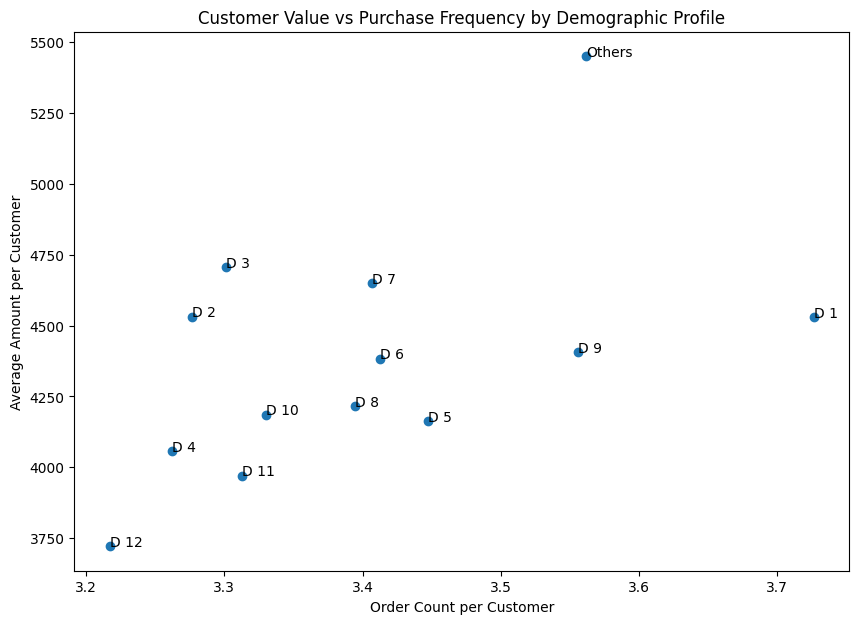

In [104]:
# Customer Value vs Purchase Frequency by Demographic Profile

plt.figure(figsize=(10, 7))

plt.scatter(
    order_count_per_customer,
    average_amount_per_customer
)

for profile in order_count_per_customer.index:
    plt.annotate(
        profile,
        (
            order_count_per_customer[profile],
            average_amount_per_customer[profile]
        )
    )

plt.xlabel("Order Count per Customer")
plt.ylabel("Average Amount per Customer")
plt.title("Customer Value vs Purchase Frequency by Demographic Profile")

plt.show()

The analysis compares Demographic Profiles based on **Order Count per Customer** and **Average Amount per Customer** to examine differences in purchase frequency and customer value.

**D 1** has the highest Order Count per Customer (**3.73**), followed by **Others (3.56)** and **D 9 (3.56)**. In terms of Average Amount per Customer, **Others** has the highest value (**5450.44**), followed by **D 3 (4707.01)** and **D 7 (4649.72)**.

The results also show that higher purchase frequency does not necessarily correspond to higher customer value. For example, **D 1** has the highest order frequency but its Average Amount per Customer (**4529.08**) is lower than D 3, D 7, and Others. Conversely, **Others** combines a relatively high purchase frequency with the highest Average Amount per Customer.

Overall, the profiles show differences between **purchase frequency and customer value**, indicating that these two measures capture different aspects of customer behavior.


#### Product Category Preference

The product category preferences of the top-performing Demographic Profiles were examined to identify the categories most frequently purchased by these customer groups.

In [105]:
# Top 5 Most Valuable Demographic Profiles
top_profiles = (
    star_score_df
    .head(5)["Demographic_Profile"]
)

# Top 3 Product Categories for Each Profile
top_categories = {}

for profile in top_profiles:
    category_counts = (
        df[df["Demographic_Profile"] == profile]
        ["Product_Category"]
        .value_counts()
        .head(3)
    )
    
    top_categories[profile] = category_counts.index.tolist()


# Convert the result into a table
product_category_table = pd.DataFrame(
    top_categories
).T

product_category_table.columns = [
    "Top 1 Product Category",
    "Top 2 Product Category",
    "Top 3 Product Category"
]

product_category_table.index.name = "Demographic Profile"

product_category_table.style

,Top 1 Product Category,Top 2 Product Category,Top 3 Product Category
Demographic Profile,,,
D 8,Beauty,Books,Sports
D 7,Sports,Food,Beauty
Others,Sports,Books,Fashion
D 5,Books,Fashion,Toys
D 1,Sports,Books,Toys


The product category analysis shows that the highest-scoring Demographic Profiles have different product preferences. **D 8** primarily prefers **Beauty**, while **D 7** shows the highest preference for **Sports**. The **Others** profile also has **Sports** as its top category, whereas **D 5** primarily prefers **Books**. **D 1** shows the highest preference for **Sports**.

Across the five profiles, **Sports** and **Books** appear most frequently among the top three product categories. This shows that these two categories are common preferences among the highest-scoring Demographic Profiles, although each profile also has its own distinct category preferences.


#### Demographic Profile Loyalty Analysis


In [106]:
# Determine the Demographic Profile of each customer
customer_profiles = (
    df.groupby("Customer_ID")["Demographic_Profile"]
    .first()
)

# Link each loyalty group to the Demographic Profile
new_customers = customer_profiles.loc[only_false.index]
short_time_returning = customer_profiles.loc[false_to_true.index]
long_time_returning = customer_profiles.loc[only_true.index]


# Calculate customer counts by Demographic Profile
new_counts = new_customers.value_counts()
short_counts = short_time_returning.value_counts()
long_counts = long_time_returning.value_counts()


# Total customer count
total_customers = customer_profiles.value_counts()


# Percentage within each Demographic Profile
new_percent = (new_counts / total_customers * 100).fillna(0)
short_percent = (short_counts / total_customers * 100).fillna(0)
long_percent = (long_counts / total_customers * 100).fillna(0)


# Display the result in a table
loyalty_by_demographic = pd.DataFrame({
    "New Customer": new_percent,
    "Short-Term Returning": short_percent,
    "Long-Term Returning": long_percent
}).fillna(0)

profile_order = [
    "D 1", "D 2", "D 3", "D 4",
    "D 5", "D 6", "D 7", "D 8",
    "D 9", "D 10", "D 11", "D 12"
]

loyalty_by_demographic = loyalty_by_demographic.reindex(profile_order)

print(loyalty_by_demographic)

                     New Customer  Short-Term Returning  Long-Term Returning
Demographic_Profile                                                         
D 1                      4.489796             36.734694            58.775510
D 2                      6.030151             37.688442            56.281407
D 3                      6.617647             27.573529            65.808824
D 4                      6.741573             34.456929            58.801498
D 5                      8.207934             34.062927            57.729138
D 6                      7.500000             33.611111            58.888889
D 7                      6.368564             33.875339            59.756098
D 8                      6.860158             32.453826            60.686016
D 9                      5.291005             33.597884            61.111111
D 10                     7.532468             30.909091            61.558442
D 11                     9.375000             28.906250            61.718750

The loyalty analysis compares the percentage of **New Customers, Short-Term Returning Customers, and Long-Term Returning Customers** within each Demographic Profile.

**D 3** has the highest proportion of Long-Term Returning customers at **65.81%**, followed by **D 11 (61.72%)**, **D 10 (61.56%)**, and **D 9 (61.11%)**. In contrast, **D 2** has the lowest proportion of Long-Term Returning customers at **56.28%**.

The share of **New Customers** is relatively low across all profiles, ranging from **4.49% to 10.38%**. **D 12** has the highest proportion of New Customers at **10.38%**, while **D 1** has the lowest at **4.49%**.

Another notable pattern is that **D 3**, which has the highest proportion of Long-Term Returning customers, also has one of the lowest shares of Short-Term Returning customers (**27.57%**). This indicates that customers in this profile are more concentrated in the long-term returning group rather than the short-term returning group.

---


### 5.3 Behavioral Profile Analysis

Behavioral Profiles were created to group customers based on their purchasing and engagement patterns.
The profiles combine several behavioral indicators to provide a broader view of how customers interact with the e-commerce platform.

The following variables were used to create the Behavioral Profiles:

* **Pages Viewed** – measures the customer's browsing activity.
* **Session Duration** – measures the time spent on the platform.
* **Returning Customer Behavior** – reflects the customer's returning purchase behavior.
* **Discount Usage** – measures the customer's tendency to purchase with discounts.
* **Quantity Purchased** – reflects the customer's purchasing volume.

The created profiles will be compared using different measures to understand how behavioral patterns vary across customer groups.


In [107]:

# BEHAVIORAL PROFILE CREATİON

# 1. Customer-level behavioral data
behavioral_data = (
    df.groupby("Customer_ID")
    .agg({
        "Pages_Viewed": "mean",
        "Session_Duration_Minutes": "mean",
        "Is_Returning_Customer": "sum",
        "Discount_Amount": "mean",
        "Total_Amount": "mean",
        "Quantity": "mean"
    })
    .reset_index()
)

# 2. Discount Rate
discount_rate = (
    df.groupby("Customer_ID")["Discount_Amount"]
    .apply(lambda x: (x > 0).mean() * 100)
    .reset_index(name="Discount_Rate")
)

behavioral_data = behavioral_data.merge(
    discount_rate,
    on="Customer_ID",
    how="left"
)

# 3. Behavioral Levels
behavioral_data["Pages_Level"] = behavioral_data["Pages_Viewed"].apply(
    lambda x: "Low" if x <= 7 else "Mid" if x <= 10 else "High"
)

behavioral_data["Session_Level"] = behavioral_data["Session_Duration_Minutes"].apply(
    lambda x: "Low" if x <= 12 else "Mid" if x <= 16 else "High"
)

behavioral_data["Returning_Level"] = behavioral_data["Is_Returning_Customer"].apply(
    lambda x: "Low" if x == 0 else "Mid" if x <= 5 else "High"
)

behavioral_data["Discount_Level"] = behavioral_data["Discount_Rate"].apply(
    lambda x: "Low" if x == 0 else "Mid" if x <= 50 else "High"
)

behavioral_data["Quantity_Level"] = behavioral_data["Quantity"].apply(
    lambda x: "Mid" if x <= 4 else "High"
)

# 4. Pattern
behavioral_data["Pattern"] = (
    behavioral_data["Pages_Level"] + "_" +
    behavioral_data["Session_Level"] + "_" +
    behavioral_data["Returning_Level"] + "_" +
    behavioral_data["Discount_Level"] + "_" +
    behavioral_data["Quantity_Level"]
)

# 5. Pattern ID
pattern_counts = (
    behavioral_data["Pattern"]
    .value_counts()
    .reset_index()
)

pattern_counts.columns = ["Pattern", "Customer_Count"]

pattern_counts["Pattern_ID"] = range(len(pattern_counts))

behavioral_data = behavioral_data.merge(
    pattern_counts[["Pattern", "Pattern_ID"]],
    on="Pattern",
    how="left"
)

# 6. Final Profile Mapping
profile_mapping = {
    0: "Standard",

    1: "No Disc. Standard",

    2: "Loyal",
    35: "Loyal",
    70: "Loyal",
    75: "Loyal",
    78: "Loyal",

    3: "Discount-Oriented",
    68: "Discount-Oriented",

    4: "Engaged",
    5: "Engaged",
    26: "Engaged",
    53: "Engaged",
    80: "Engaged",

    6: "No-Disc. Engaged",
    7: "No-Disc. Engaged",
    19: "No-Disc. Engaged",
    30: "No-Disc. Engaged",
    77: "No-Disc. Engaged",

    8: "Disc.-Oriented Engaged",
    9: "Disc.-Oriented Engaged",
    25: "Disc.-Oriented Engaged",
    40: "Disc.-Oriented Engaged",
    49: "Disc.-Oriented Engaged",

    10: "Disc.-Engaged Loyal",
    18: "Disc.-Engaged Loyal",
    24: "Disc.-Engaged Loyal",
    54: "Disc.-Engaged Loyal",
    74: "Disc.-Engaged Loyal",

    11: "Quick Buyers",
    12: "Quick Buyers",
    13: "Quick Buyers",
    14: "Quick Buyers",
    32: "Quick Buyers",
    56: "Quick Buyers",
    58: "Quick Buyers",

    15: "Bulk Buyers",
    17: "Bulk Buyers",
    23: "Bulk Buyers",
    36: "Bulk Buyers",
    38: "Bulk Buyers",
    39: "Bulk Buyers",
    42: "Bulk Buyers",
    45: "Bulk Buyers",
    55: "Bulk Buyers",
    59: "Bulk Buyers",
    64: "Bulk Buyers",
    66: "Bulk Buyers",
    72: "Bulk Buyers",

    16: "Disc.-Oriented Quick",
    20: "Disc.-Oriented Quick",
    33: "Disc.-Oriented Quick",
    47: "Disc.-Oriented Quick",
    50: "Disc.-Oriented Quick",
    76: "Disc.-Oriented Quick",

    22: "No-Disc. New Customers",
    29: "No-Disc. New Customers",
    37: "No-Disc. New Customers",
    41: "No-Disc. New Customers",
    46: "No-Disc. New Customers",
    51: "No-Disc. New Customers",
    57: "No-Disc. New Customers",
    61: "No-Disc. New Customers",
    62: "No-Disc. New Customers",
    69: "No-Disc. New Customers",
    71: "No-Disc. New Customers",
    81: "No-Disc. New Customers",

    27: "Quick Explorers",
    28: "Quick Explorers",

    21: "Slow Explorers",
    34: "Slow Explorers",
    43: "Slow Explorers",

    31: "Disc.-Oriented New Customers",
    44: "Disc.-Oriented New Customers",
    48: "Disc.-Oriented New Customers",
    52: "Disc.-Oriented New Customers",
    60: "Disc.-Oriented New Customers",
    63: "Disc.-Oriented New Customers",
    67: "Disc.-Oriented New Customers",
    73: "Disc.-Oriented New Customers",
    79: "Disc.-Oriented New Customers"
}

# 7. Assign Behavioral Profile
behavioral_data["Behavioral_Profile"] = (
    behavioral_data["Pattern_ID"].map(profile_mapping)
)

# 8. Unmapped patterns -> Other
behavioral_data["Behavioral_Profile"] = (
    behavioral_data["Behavioral_Profile"]
    .fillna("Other")
)

# 9. Add Behavioral Profile to main df
df = df.merge(
    behavioral_data[["Customer_ID", "Behavioral_Profile"]],
    on="Customer_ID",
    how="left"
)

# 10. Check result
print(df["Behavioral_Profile"].value_counts())

Behavioral_Profile
Loyal                           3650
Standard                        3405
Discount-Oriented               1459
Engaged                         1451
Disc.-Oriented Engaged          1309
Disc.-Engaged Loyal             1158
No Disc. Standard               1147
Quick Buyers                     866
No-Disc. Engaged                 756
Bulk Buyers                      744
Disc.-Oriented Quick             371
No-Disc. New Customers           186
Other                            159
Slow Explorers                   145
Quick Explorers                  141
Disc.-Oriented New Customers     102
Name: count, dtype: int64


In [108]:
df['Behavioral_Profile'].head(50)

0                   Standard
1                   Standard
2                   Standard
3                   Standard
4                   Standard
5               Quick Buyers
6               Quick Buyers
7                      Other
8          No Disc. Standard
9          No Disc. Standard
10         No Disc. Standard
11                  Standard
12                  Standard
13                  Standard
14    Disc.-Oriented Engaged
15                   Engaged
16                   Engaged
17                   Engaged
18    No-Disc. New Customers
19         No Disc. Standard
20         No Disc. Standard
21         No Disc. Standard
22                     Loyal
23                     Loyal
24                     Loyal
25                     Loyal
26                     Loyal
27                     Loyal
28                     Loyal
29    No-Disc. New Customers
30              Quick Buyers
31              Quick Buyers
32              Quick Buyers
33              Quick Buyers
34            

### Behavioral Profile Creation

To identify customer behavior, customer-level data was created based on `Customer_ID`. This approach ensures that each customer is evaluated as an individual rather than based on separate orders.

Five behavioral indicators were used to create the profiles:

* **Pages Viewed** – reflects the customer's browsing activity.
* **Session Duration** – reflects the time the customer spends on the platform.
* **Returning Customer** – reflects the customer's returning purchase behavior.
* **Discount Rate** – represents the percentage of the customer's orders where a discount was applied.
* **Quantity** – reflects the average number of products purchased per order.

Each indicator was converted into behavioral levels based on predefined ranges. **Pages Viewed** and **Session Duration** were classified into **Low, Mid, and High** levels according to the customer's browsing and engagement intensity. **Returning Customer** was classified based on the customer's returning purchase frequency. **Discount Rate** was classified according to how frequently the customer purchased with a discount, while **Quantity** was used to distinguish customers based on their purchasing volume.

The five resulting levels were then combined to create a unique **behavioral pattern** for each customer. For example, a customer could have a specific combination of browsing, session, returning, discount, and quantity levels. Customers with similar behavioral patterns were then grouped together into broader Behavioral Profiles.

This process resulted in **15 Behavioral Profiles**, each representing a distinct combination of customer purchasing and engagement characteristics. Customers whose patterns did not match the predefined profile groups were classified separately as **Other**.


### Behavioral Profile Characteristics

Each Behavioral Profile represents a specific combination of customer behaviors. The profiles were named according to their dominant characteristics across browsing activity, session duration, returning behavior, discount usage, and purchase quantity.

| **Behavioral Profile**           | **Main Characteristics**                                                                              |
| -------------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Standard**                     | Customers with a relatively balanced behavioral pattern across the selected indicators.               |
| **No Disc. Standard**            | Customers with a standard behavioral pattern who do not use discounts.                                |
| **Loyal**                        | Customers with a strong returning-customer behavior, indicating a higher level of customer loyalty.   |
| **Discount-Oriented**            | Customers who frequently purchase using discounts.                                                    |
| **Engaged**                      | Customers with higher browsing activity and longer engagement with the platform.                      |
| **No-Disc. Engaged**             | Highly engaged customers who do not use discounts.                                                    |
| **Disc.-Oriented Engaged**       | Highly engaged customers who also show a strong tendency to use discounts.                            |
| **Disc.-Engaged Loyal**          | Customers combining strong engagement, returning behavior, and frequent discount usage.               |
| **Quick Buyers**                 | Customers with relatively low browsing and shorter sessions, indicating a quicker purchasing process. |
| **Bulk Buyers**                  | Customers characterized by higher purchase quantities.                                                |
| **Disc.-Oriented Quick**         | Quick-purchasing customers who frequently use discounts.                                              |
| **No-Disc. New Customers**       | New customers who have not yet developed returning behavior and do not use discounts.                 |
| **Quick Explorers**              | Customers who browse and explore the platform but have relatively shorter sessions.                   |
| **Slow Explorers**               | Customers who spend more time exploring the platform before completing purchases.                     |
| **Disc.-Oriented New Customers** | New customers who do not yet show returning behavior but frequently use discounts.                    |
| **Other**                        | Customers whose behavioral patterns did not match the predefined profile groups.                      |

These profiles provide a structured way to distinguish customers based on how they browse, engage, return, use discounts, and purchase products.


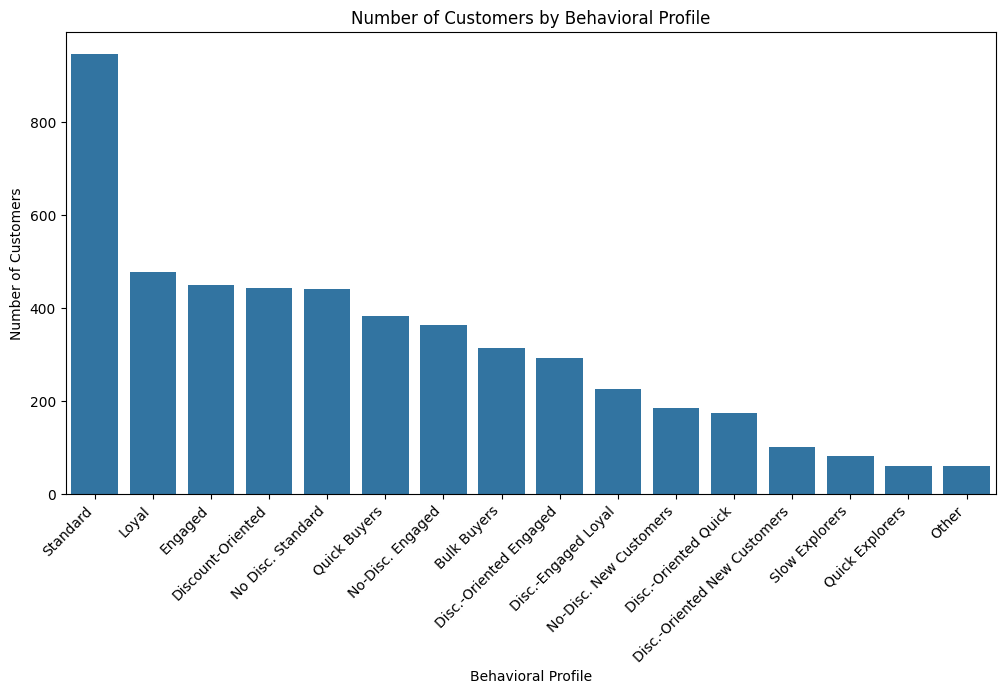

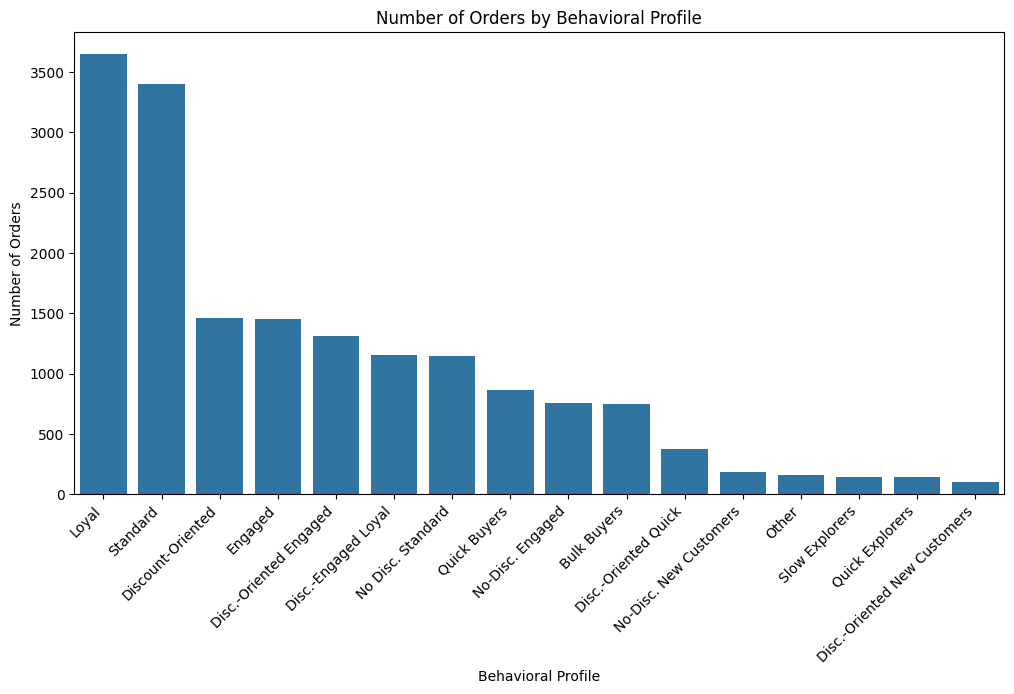

In [109]:
# Customer Count by Behavioral Profile

customer_count2 = (
    df.groupby("Behavioral_Profile")["Customer_ID"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=customer_count2.index,
    y=customer_count2.values
)

plt.title("Number of Customers by Behavioral Profile")
plt.xlabel("Behavioral Profile")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.show()


# Order Count by Behavioral Profile

order_count2 = (
    df.groupby("Behavioral_Profile")["Order_ID"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=order_count2.index,
    y=order_count2.values
)

plt.title("Number of Orders by Behavioral Profile")
plt.xlabel("Behavioral Profile")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.show()

* **1st chart →** Shows how many unique customers belong to each Behavioral Profile.
* **2nd chart →** Shows how many orders were generated by each Behavioral Profile.

Although **Standard** is the largest profile by customer count, **Loyal** customers generate more orders. This suggests that Loyal customers purchase more frequently than Standard customers.

Therefore, the number of customers alone does not fully reflect the importance of a Behavioral Profile. The higher order activity of Loyal customers highlights their stronger contribution to the business.


#### Behavioral Profile Performance Ranking

Behavioral Profiles were compared using **8 performance indicators** to evaluate their overall performance and customer value.

The indicators used in the ranking are:

* **Customer Count** – the number of unique customers in each Behavioral Profile.
* **Total Order Count** – the total number of unique orders generated by each profile.
* **Order Count per Customer** – the average number of orders generated by each customer within the profile.
* **Total Amount** – the total sales amount generated by each profile.
* **Average Amount per Customer** – the average total sales amount generated per customer within the profile.
* **Average Quantity per Order** – the average number of products purchased in each order.
* **Average Amount per Order** – the average sales amount generated from each order.
* **Revenue Contribution (%)** – the percentage of total revenue generated by each Behavioral Profile.

For each indicator, the **Top 3 Behavioral Profiles** were identified. The 1st-place profile received **3 ⭐**, the 2nd-place profile received **2 ⭐**, and the 3rd-place profile received **1 ⭐**. The stars from all eight indicators were then combined to create an overall performance ranking of the Behavioral Profiles.


In [110]:
# Behavioral Profile Performance Ranking

# Behavioral Profile üzrə əsas göstəricilər

# Customer Count
profile_counts2 = (
    df.groupby("Behavioral_Profile")["Customer_ID"]
    .nunique()
)

# Total Order Count
order_count2 = (
    df.groupby("Behavioral_Profile")["Order_ID"]
    .nunique()
)

# Order Count per Customer
order_count_per_customer2 = order_count2 / profile_counts2

# Total Amount
total_amount2 = (
    df.groupby("Behavioral_Profile")["Total_Amount"]
    .sum()
)

# Average Amount per Customer
average_amount_per_customer2 = total_amount2 / profile_counts2


# Bütün kateqoriyalar üzrə Top 3

top_3_customer_count2 = (
    profile_counts2
    .sort_values(ascending=False)
    .head(3)
)

top_3_total_order_count2 = (
    order_count2
    .sort_values(ascending=False)
    .head(3)
)

top_3_order_count_per_customer2 = (
    order_count_per_customer2
    .sort_values(ascending=False)
    .head(3)
)

top_3_total_amount2 = (
    total_amount2
    .sort_values(ascending=False)
    .head(3)
)

top_3_average_amount_per_customer2 = (
    average_amount_per_customer2
    .sort_values(ascending=False)
    .head(3)
)


# Total Quantity
total_quantity2 = (
    df.groupby("Behavioral_Profile")["Quantity"]
    .sum()
)


# Additional Value Metrics

# Average Quantity per Order
average_quantity_per_order2 = (
    total_quantity2 / order_count2
)

# Average Amount per Order
average_amount_per_order2 = (
    total_amount2 / order_count2
)

# Revenue Contribution (%)
revenue_contribution2 = (
    total_amount2 / df["Total_Amount"].sum() * 100
)


# Top 3 for Additional Metrics

top_3_average_quantity_per_order2 = (
    average_quantity_per_order2
    .sort_values(ascending=False)
    .head(3)
)

top_3_average_amount_per_order2 = (
    average_amount_per_order2
    .sort_values(ascending=False)
    .head(3)
)

top_3_revenue_contribution2 = (
    revenue_contribution2
    .sort_values(ascending=False)
    .head(3)
)


# Display Top 3 with Star System

print("Customer Count")
for i, (profile, value) in enumerate(top_3_customer_count2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value} {stars}")


print("\nTotal Order Count")
for i, (profile, value) in enumerate(top_3_total_order_count2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value} {stars}")


print("\nOrder Count per Customer")
for i, (profile, value) in enumerate(top_3_order_count_per_customer2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value:.2f} {stars}")


print("\nTotal Amount")
for i, (profile, value) in enumerate(top_3_total_amount2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value:.2f} {stars}")


print("\nAverage Amount per Customer")
for i, (profile, value) in enumerate(top_3_average_amount_per_customer2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value:.2f} {stars}")


print("\nAverage Quantity per Order")
for i, (profile, value) in enumerate(top_3_average_quantity_per_order2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value:.2f} {stars}")


print("\nAverage Amount per Order")
for i, (profile, value) in enumerate(top_3_average_amount_per_order2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value:.2f} {stars}")


print("\nRevenue Contribution (%)")
for i, (profile, value) in enumerate(top_3_revenue_contribution2.items(), 1):
    stars = "★" * (4 - i)
    print(f"{profile}: {value:.2f}% {stars}")





Customer Count
Standard: 946 ★★★
Loyal: 477 ★★
Engaged: 450 ★

Total Order Count
Loyal: 3650 ★★★
Standard: 3405 ★★
Discount-Oriented: 1459 ★

Order Count per Customer
Loyal: 7.65 ★★★
Disc.-Engaged Loyal: 5.12 ★★
Disc.-Oriented Engaged: 4.48 ★

Total Amount
Loyal: 4855759.21 ★★★
Standard: 4076943.78 ★★
Engaged: 1772503.81 ★

Average Amount per Customer
Loyal: 10179.79 ★★★
Disc.-Engaged Loyal: 6657.65 ★★
Disc.-Oriented Engaged: 5585.17 ★

Average Quantity per Order
Bulk Buyers: 4.57 ★★★
Other: 3.87 ★★
No-Disc. New Customers: 3.12 ★

Average Amount per Order
Bulk Buyers: 2061.14 ★★★
Other: 1732.41 ★★
No-Disc. Engaged: 1400.64 ★

Revenue Contribution (%)
Loyal: 22.30% ★★★
Standard: 18.72% ★★
Engaged: 8.14% ★


In [111]:
# Overall Performance Ranking

# Initialize total star scores
star_score2 = pd.Series(0, index=profile_counts2.index)


# Customer Count
for i, profile in enumerate(top_3_customer_count2.index, 1):
    star_score2[profile] += 4 - i


# Total Order Count
for i, profile in enumerate(top_3_total_order_count2.index, 1):
    star_score2[profile] += 4 - i


# Order Count per Customer
for i, profile in enumerate(top_3_order_count_per_customer2.index, 1):
    star_score2[profile] += 4 - i


# Total Amount
for i, profile in enumerate(top_3_total_amount2.index, 1):
    star_score2[profile] += 4 - i


# Average Amount per Customer
for i, profile in enumerate(top_3_average_amount_per_customer2.index, 1):
    star_score2[profile] += 4 - i


# Average Quantity per Order
for i, profile in enumerate(top_3_average_quantity_per_order2.index, 1):
    star_score2[profile] += 4 - i


# Average Amount per Order
for i, profile in enumerate(top_3_average_amount_per_order2.index, 1):
    star_score2[profile] += 4 - i


# Revenue Contribution (%)
for i, profile in enumerate(top_3_revenue_contribution2.index, 1):
    star_score2[profile] += 4 - i


# Overall Ranking
overall_ranking2 = (
    star_score2
    .sort_values(ascending=False)
)

overall_ranking2

Behavioral_Profile
Loyal                           17
Standard                         9
Bulk Buyers                      6
Disc.-Engaged Loyal              4
Other                            4
Engaged                          3
Disc.-Oriented Engaged           2
Discount-Oriented                1
No-Disc. New Customers           1
No-Disc. Engaged                 1
Disc.-Oriented Quick             0
Disc.-Oriented New Customers     0
No Disc. Standard                0
Quick Buyers                     0
Quick Explorers                  0
Slow Explorers                   0
dtype: int64

In [112]:

# Overall Performance Ranking Table

overall_ranking_table2 = (
    overall_ranking2
    .reset_index()
)

overall_ranking_table2.columns = [
    "Behavioral_Profile",
    "Total_Stars"
]

overall_ranking_table2["Stars"] = (
    overall_ranking_table2["Total_Stars"]
    .apply(lambda x: "★" * x)
)

overall_ranking_table2

,Behavioral_Profile,Total_Stars,Stars
0,Loyal,17,★★★★★★★★★★★★★★★★★
1,Standard,9,★★★★★★★★★
2,Bulk Buyers,6,★★★★★★
3,Disc.-Engaged Loyal,4,★★★★
4,Other,4,★★★★
5,Engaged,3,★★★
6,Disc.-Oriented Engaged,2,★★
7,Discount-Oriented,1,★
8,No-Disc. New Customers,1,★
9,No-Disc. Engaged,1,★


The overall performance ranking shows clear differences between the Behavioral Profiles. **Loyal** is the highest-performing profile, with **17 stars** across the eight performance indicators. **Standard** follows with **9 stars**, while **Bulk Buyers** ranks third with **6 stars**.

The strong performance of the **Loyal** profile indicates that these customers contribute across multiple dimensions, including customer activity, order frequency, purchasing value, and purchase quantity. In contrast, most other profiles receive considerably fewer stars, suggesting that their performance is concentrated in fewer indicators.

This result highlights that **customer loyalty is an important characteristic associated with stronger overall customer performance** in the dataset.


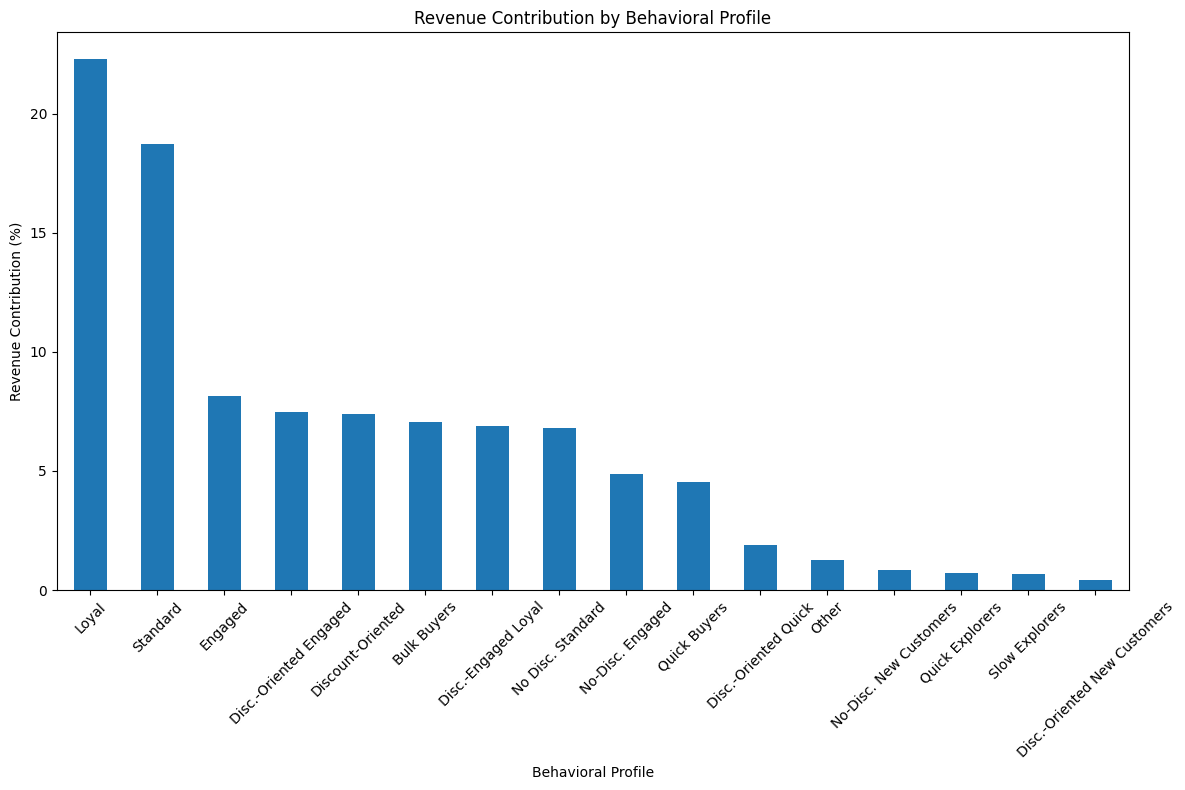

In [113]:
# Visualizing Revenue Contribution by Behavioral Profile

plt.figure(figsize=(12, 8))

revenue_contribution2.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue Contribution by Behavioral Profile")
plt.xlabel("Behavioral Profile")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The revenue contribution analysis shows that **Loyal** customers generate the largest share of total revenue at **22.30%**, followed by **Standard** customers with **18.72%**. **Engaged** customers rank third, contributing **8.14%** of total revenue.

These results show that revenue is concentrated among a small number of Behavioral Profiles, with Loyal customers making the largest contribution to overall revenue.


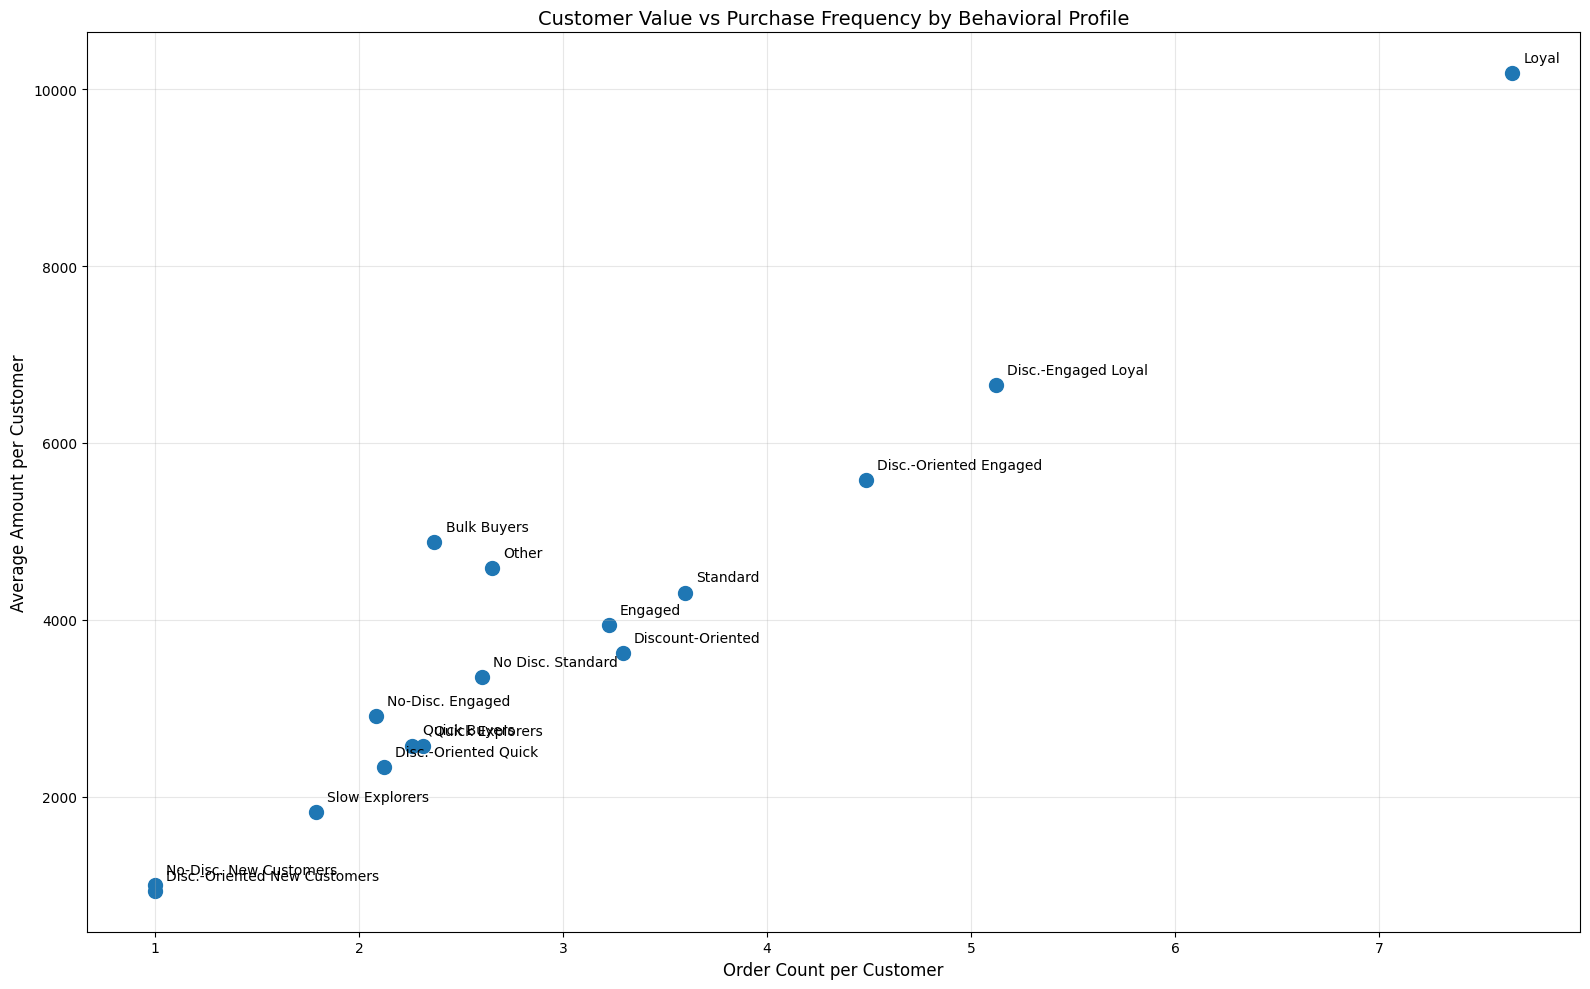

In [114]:
# Customer Value vs Purchase Frequency

plt.figure(figsize=(16, 10))

plt.scatter(
    order_count_per_customer2,
    average_amount_per_customer2,
    s=100
)

for profile in order_count_per_customer2.index:
    plt.annotate(
        profile,
        (
            order_count_per_customer2[profile],
            average_amount_per_customer2[profile]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10
    )

plt.xlabel("Order Count per Customer", fontsize=12)
plt.ylabel("Average Amount per Customer", fontsize=12)
plt.title(
    "Customer Value vs Purchase Frequency by Behavioral Profile",
    fontsize=14
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Loyal** customers show relatively high purchase frequency and average customer value, while several other profiles have lower values on both measures. Overall, the profiles show a **positive pattern between purchase frequency and average customer value**.


In [115]:
profile_category_pct = pd.crosstab(
    df["Behavioral_Profile"],
    df["Product_Category"],
    normalize="index"
) * 100

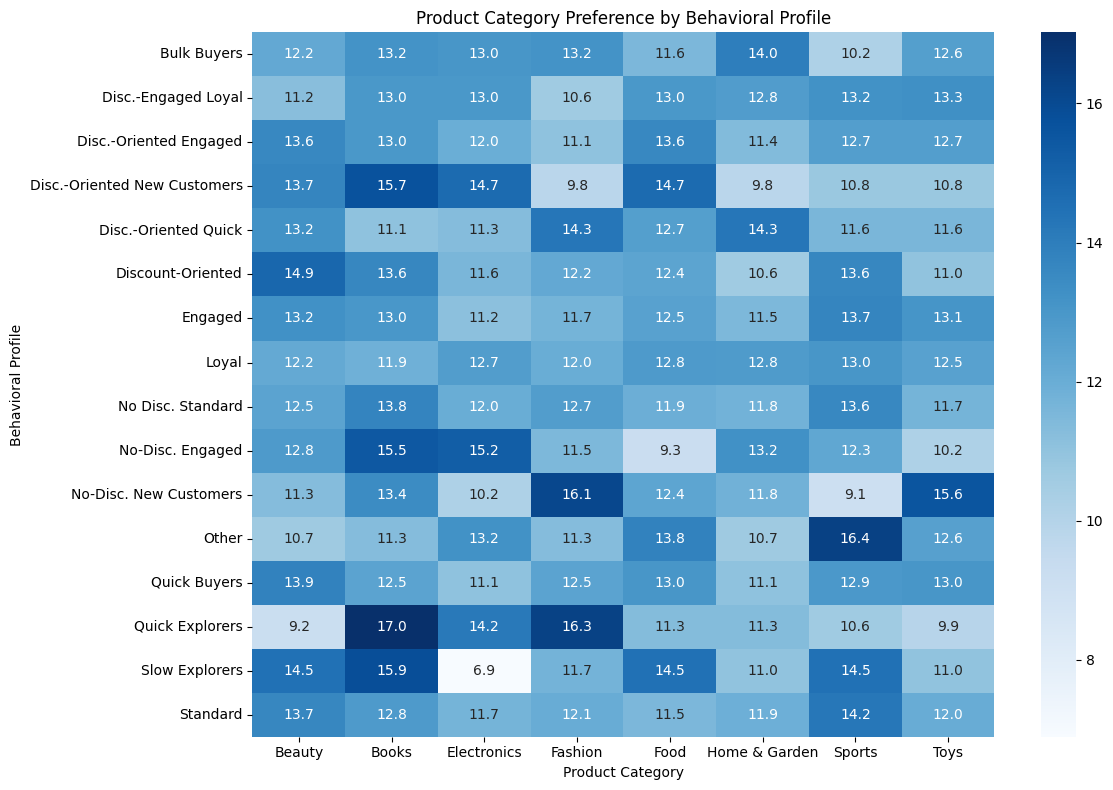

In [116]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    profile_category_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Product Category Preference by Behavioral Profile")
plt.xlabel("Product Category")
plt.ylabel("Behavioral Profile")

plt.tight_layout()
plt.show()

Product preferences vary across Behavioral Profiles. **Quick Explorers** show the highest preference for **Books (17.02%)**, while **No-Disc. New Customers** have the highest share in **Fashion (16.13%)**. **Other** customers show the highest preference for **Sports (16.35%)**, and **Slow Explorers** also show a relatively high preference for **Books (15.86%)**.

Overall, the heatmap shows that different behavioral profiles have distinct product category preferences.


### Demographic & Behavioral Profile Combination Analysis

The Demographic and Behavioral Profiles are combined to examine how demographic characteristics and customer behavior interact within the same customer groups.

This analysis focuses on the characteristics, customer value, and distribution of different Demographic and Behavioral Profile combinations.


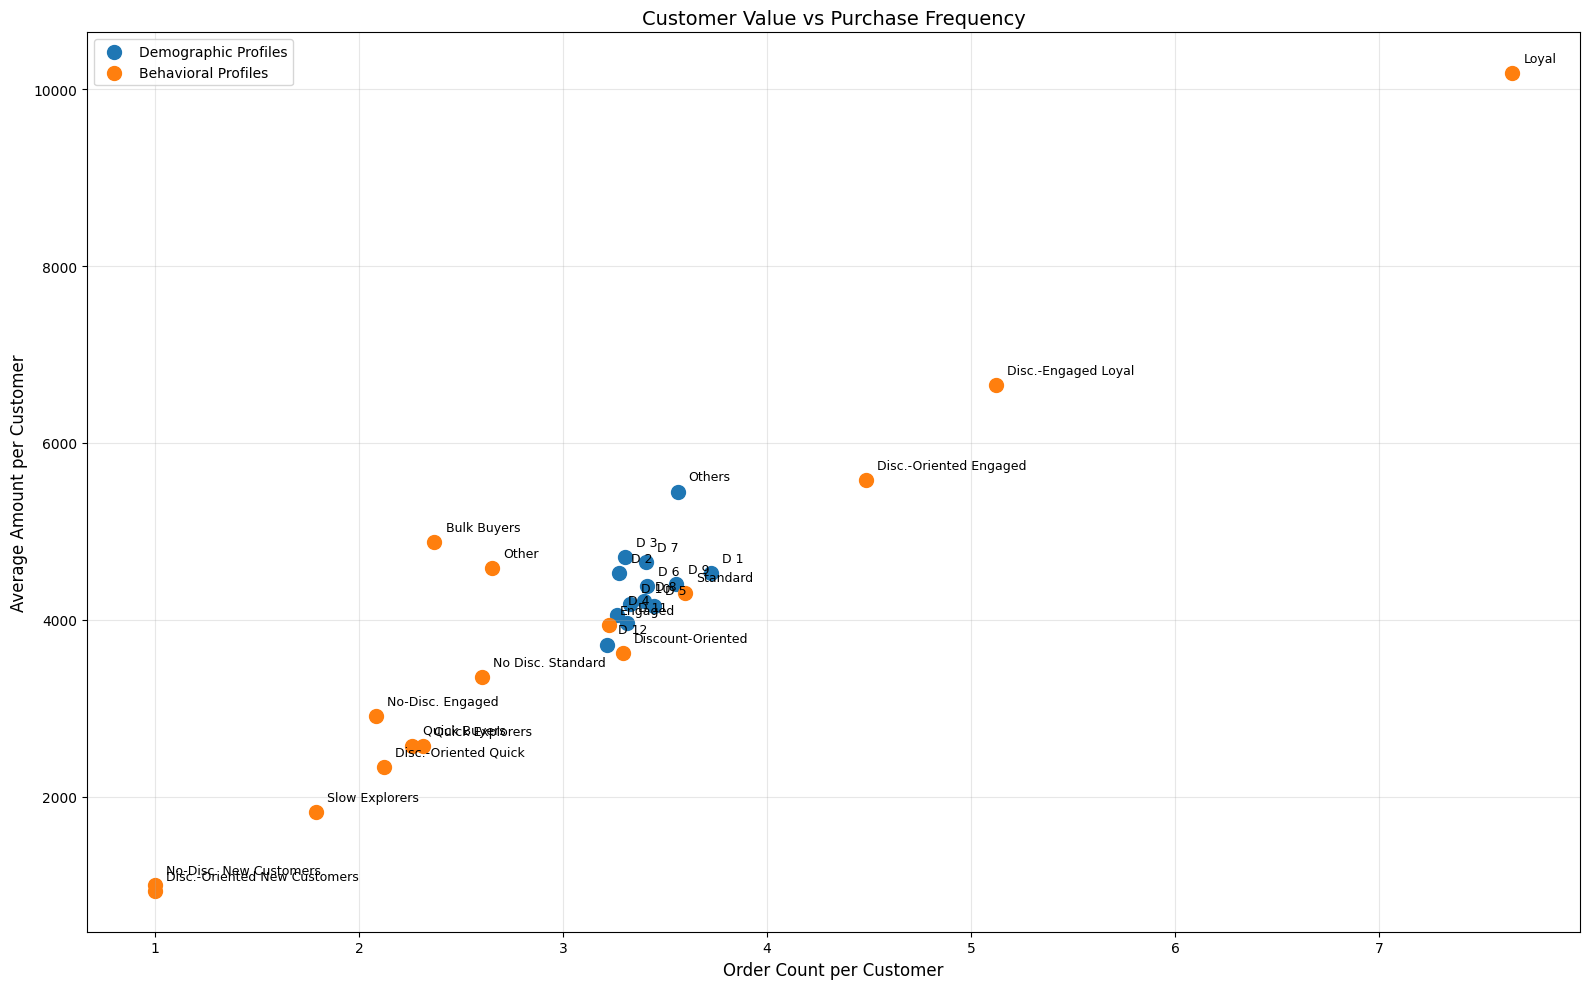

In [118]:
# Customer Value vs Purchase Frequency

# Demographic Profiles
demographic_customer_count2 = (
    df.groupby("Demographic_Profile")["Customer_ID"]
    .nunique()
)

demographic_order_count2 = (
    df.groupby("Demographic_Profile")["Order_ID"]
    .nunique()
)

demographic_order_count_per_customer2 = (
    demographic_order_count2 / demographic_customer_count2
)

demographic_total_amount2 = (
    df.groupby("Demographic_Profile")["Total_Amount"]
    .sum()
)

demographic_average_amount_per_customer2 = (
    demographic_total_amount2 / demographic_customer_count2
)


# Behavioral Profiles
behavioral_customer_count2 = (
    df.groupby("Behavioral_Profile")["Customer_ID"]
    .nunique()
)

behavioral_order_count2 = (
    df.groupby("Behavioral_Profile")["Order_ID"]
    .nunique()
)

behavioral_order_count_per_customer2 = (
    behavioral_order_count2 / behavioral_customer_count2
)

behavioral_total_amount2 = (
    df.groupby("Behavioral_Profile")["Total_Amount"]
    .sum()
)

behavioral_average_amount_per_customer2 = (
    behavioral_total_amount2 / behavioral_customer_count2
)


# Scatter Plot

plt.figure(figsize=(16, 10))

# Demographic Profiles
plt.scatter(
    demographic_order_count_per_customer2,
    demographic_average_amount_per_customer2,
    s=100,
    label="Demographic Profiles"
)

for profile in demographic_order_count_per_customer2.index:
    plt.annotate(
        profile,
        (
            demographic_order_count_per_customer2[profile],
            demographic_average_amount_per_customer2[profile]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9
    )


# Behavioral Profiles
plt.scatter(
    behavioral_order_count_per_customer2,
    behavioral_average_amount_per_customer2,
    s=100,
    label="Behavioral Profiles"
)

for profile in behavioral_order_count_per_customer2.index:
    plt.annotate(
        profile,
        (
            behavioral_order_count_per_customer2[profile],
            behavioral_average_amount_per_customer2[profile]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9
    )


plt.xlabel("Order Count per Customer", fontsize=12)
plt.ylabel("Average Amount per Customer", fontsize=12)

plt.title(
    "Customer Value vs Purchase Frequency",
    fontsize=14
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot shows that **Behavioral Profiles** are more widely distributed across customer value and purchase frequency, while **Demographic Profiles are mainly concentrated around the center of the chart**.

This indicates that behavioral characteristics create greater variation in customer purchasing frequency and value, whereas demographic characteristics show more similar patterns across the different demographic groups.


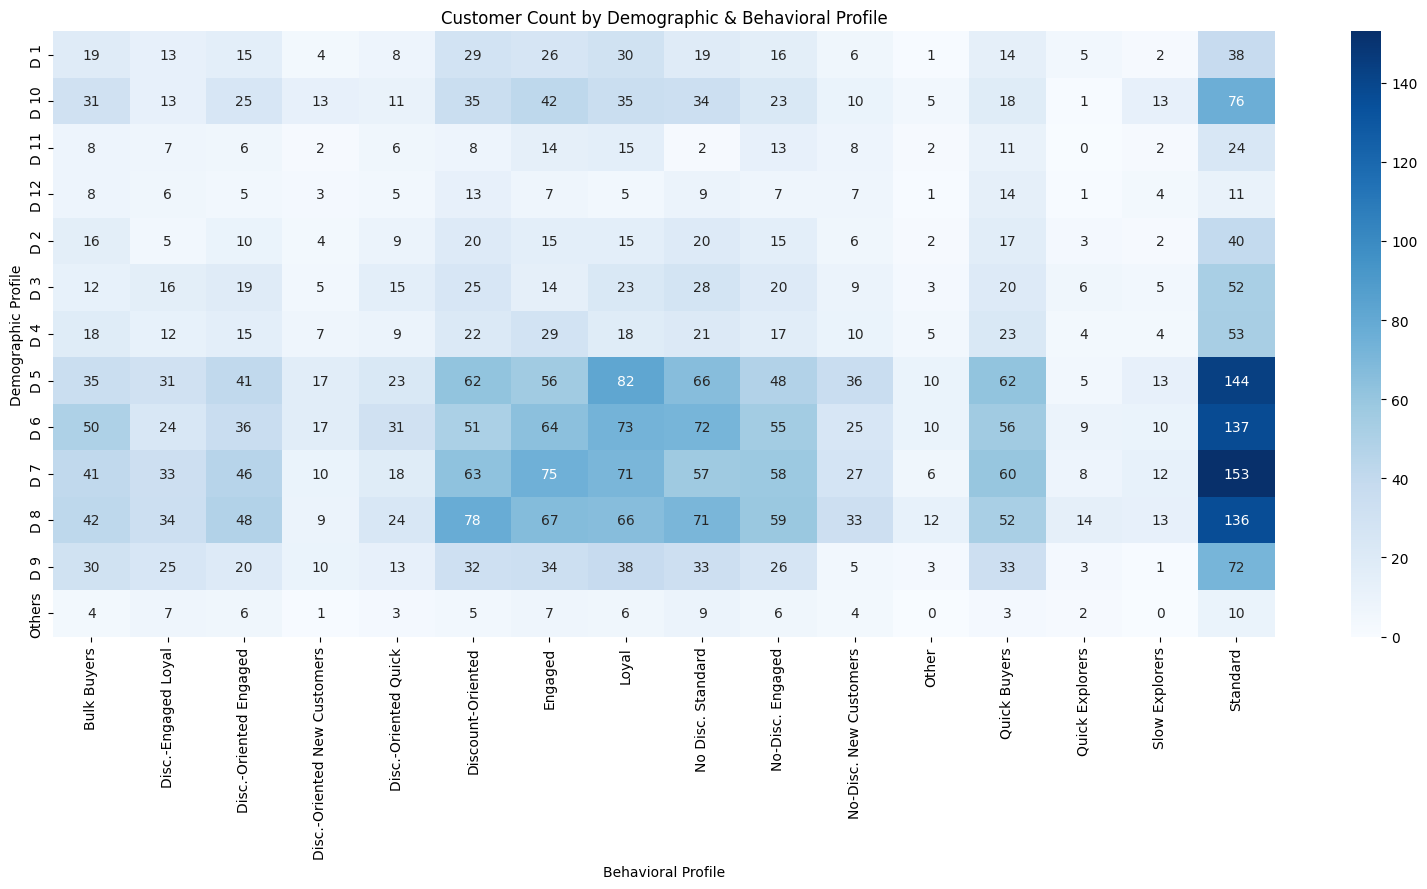

In [120]:
# Customer Count by Demographic & Behavioral Profile

demographic_behavioral_customer_count = (
    df.groupby(
        ["Demographic_Profile", "Behavioral_Profile"]
    )["Customer_ID"]
    .nunique()
    .unstack(fill_value=0)
)

plt.figure(figsize=(16, 9))

sns.heatmap(
    demographic_behavioral_customer_count,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Customer Count by Demographic & Behavioral Profile")
plt.xlabel("Behavioral Profile")
plt.ylabel("Demographic Profile")

plt.tight_layout()
plt.show()

The heatmap shows clear differences in customer concentration across Demographic and Behavioral Profile combinations.

The largest combination is **D7 + Standard**, with **153 customers**, followed by **D5 + Standard** with **144 customers** and **D6 + Standard** with **137 customers**. **D8 + Discount-Oriented** also represents a relatively large group with **78 customers**.

Overall, the **Standard** Behavioral Profile has the highest customer counts across several of the larger Demographic Profiles, particularly **D5, D6, D7, and D8**. This indicates that the concentration of customers within these demographic groups is strongly associated with the Standard behavioral pattern.

In contrast, several combinations contain very few customers. For example, **D11 + Slow Explorers** and **Others + Quick Explorers** each contain only **0 customers**, while **D1 + Quick Explorers** contains just **1 customer**.

These results show that customer distribution is not uniform across Demographic and Behavioral Profile combinations, with some combinations representing substantially larger customer groups than others.


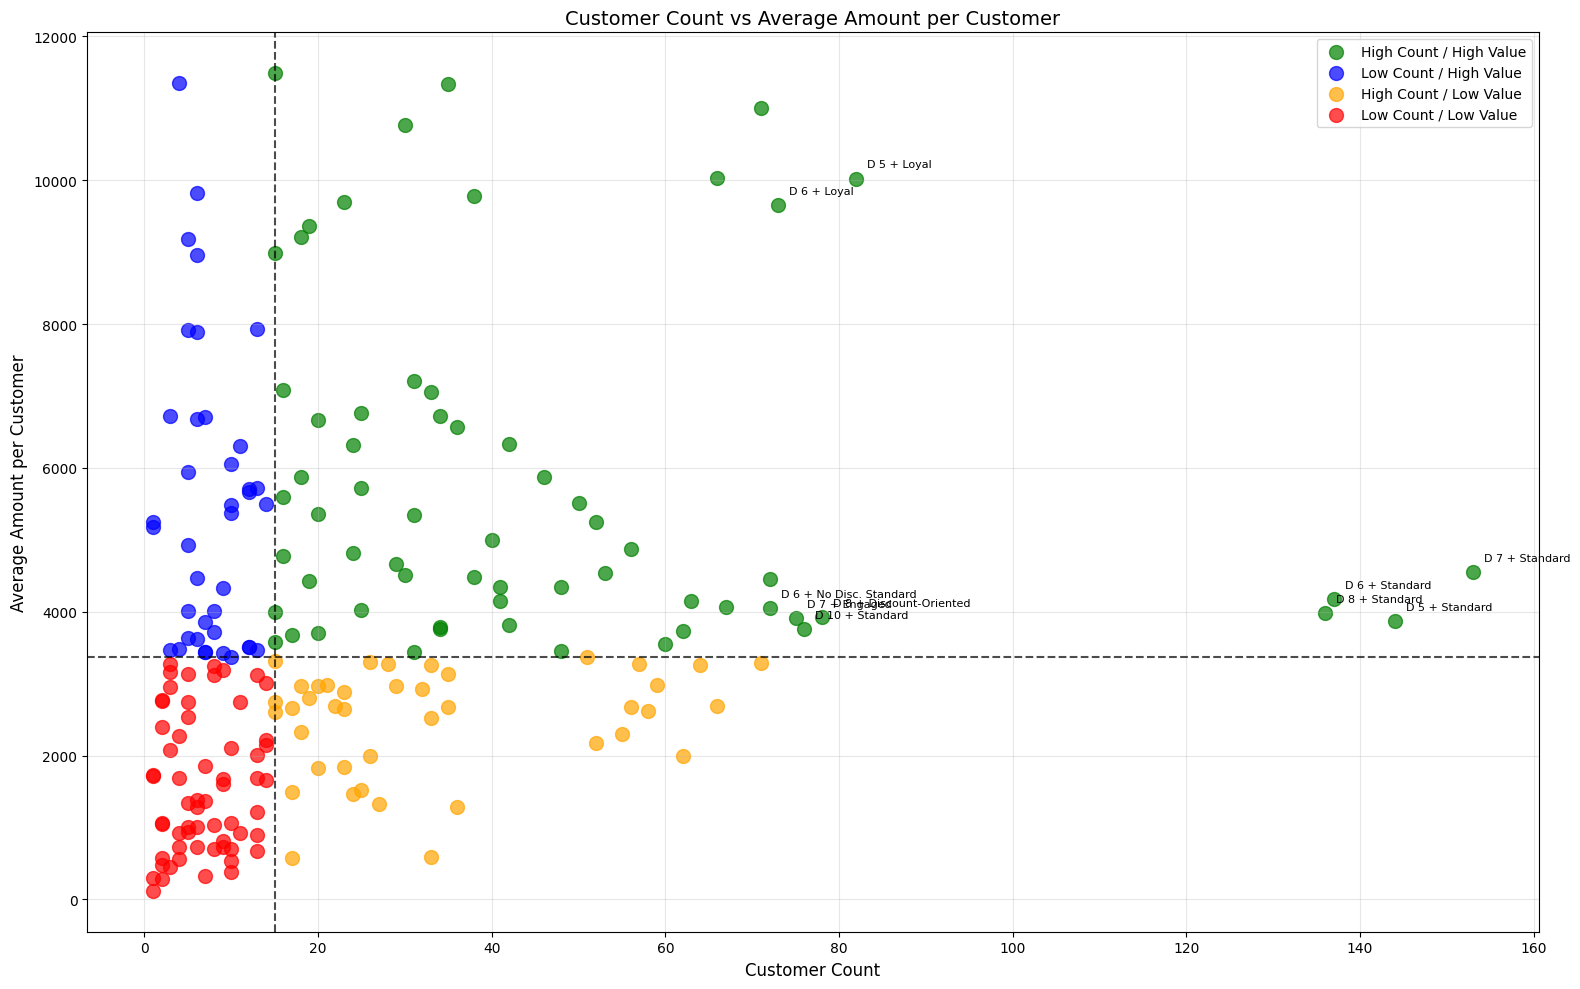

In [124]:
# Customer Count vs Average Amount per Customer
# Four Quadrants

combination_customer_count = (
    df.groupby(
        ["Demographic_Profile", "Behavioral_Profile"]
    )["Customer_ID"]
    .nunique()
)

combination_total_amount = (
    df.groupby(
        ["Demographic_Profile", "Behavioral_Profile"]
    )["Total_Amount"]
    .sum()
)

combination_average_amount_per_customer = (
    combination_total_amount / combination_customer_count
)


# Median values for quadrant boundaries
customer_count_median = combination_customer_count.median()
average_amount_median = combination_average_amount_per_customer.median()


# Determine quadrant for each combination
quadrant = pd.Series(
    index=combination_customer_count.index,
    dtype="object"
)

for combination in combination_customer_count.index:
    
    customer_count = combination_customer_count[combination]
    average_amount = combination_average_amount_per_customer[combination]
    
    if customer_count >= customer_count_median and average_amount >= average_amount_median:
        quadrant[combination] = "High Count / High Value"
        
    elif customer_count < customer_count_median and average_amount >= average_amount_median:
        quadrant[combination] = "Low Count / High Value"
        
    elif customer_count >= customer_count_median and average_amount < average_amount_median:
        quadrant[combination] = "High Count / Low Value"
        
    else:
        quadrant[combination] = "Low Count / Low Value"


# Colors for quadrants
quadrant_colors = {
    "High Count / High Value": "green",
    "Low Count / High Value": "blue",
    "High Count / Low Value": "orange",
    "Low Count / Low Value": "red"
}


plt.figure(figsize=(16, 10))

# Plot each quadrant
for quadrant_name, color in quadrant_colors.items():
    
    mask = quadrant == quadrant_name
    
    plt.scatter(
        combination_customer_count[mask],
        combination_average_amount_per_customer[mask],
        s=100,
        color=color,
        alpha=0.7,
        label=quadrant_name
    )


# Median lines
plt.axvline(
    customer_count_median,
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axhline(
    average_amount_median,
    color="black",
    linestyle="--",
    alpha=0.7
)


# Label Top 10 combinations by customer count
top_10_combinations = (
    combination_customer_count
    .sort_values(ascending=False)
    .head(10)
)

for combination in top_10_combinations.index:
    
    profile_name = f"{combination[0]} + {combination[1]}"
    
    plt.annotate(
        profile_name,
        (
            combination_customer_count[combination],
            combination_average_amount_per_customer[combination]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel("Customer Count", fontsize=12)
plt.ylabel("Average Amount per Customer", fontsize=12)

plt.title(
    "Customer Count vs Average Amount per Customer",
    fontsize=14
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot shows that customer combinations are distributed across four distinct groups based on **customer count** and **average customer value**. This helps identify combinations with a large customer base, high customer value, or both, while also highlighting smaller combinations with relatively higher or lower customer value.


Top 3 Most Valuable Combinations:
Demographic_Profile  Behavioral_Profile
D 5                  Loyal                 821831.79
D 7                  Loyal                 780904.41
D 6                  Loyal                 704780.61
Name: Total_Amount, dtype: float64


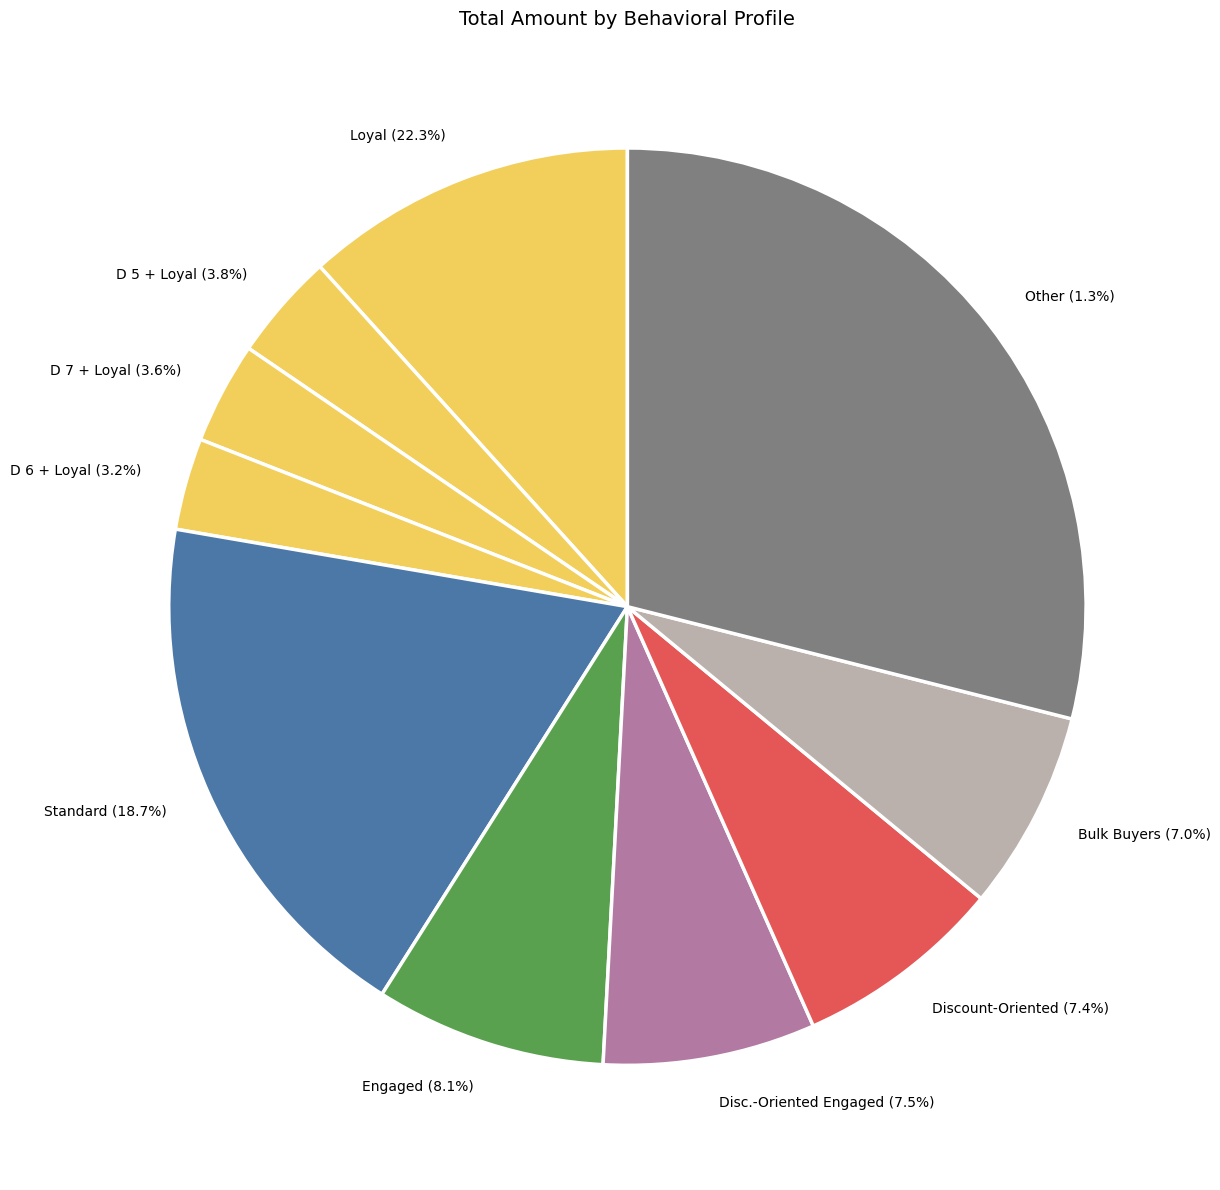

In [153]:
# Total Amount by Behavioral Profile

behavioral_total_amount = (
    df.groupby("Behavioral_Profile")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Total revenue

total_amount = behavioral_total_amount.sum()

# Behavioral Profile percentages

behavioral_percentage = (
    behavioral_total_amount / total_amount * 100
)

# Profiles below 7% → Other

main_profiles = behavioral_total_amount[
    behavioral_percentage >= 7
]

other_amount = behavioral_total_amount[
    behavioral_percentage < 7
].sum()


# Find Top 3 most valuable Demographic + Behavioral combinations

combination_total_amount = (
    df.groupby(
        ["Demographic_Profile", "Behavioral_Profile"]
    )["Total_Amount"]
    .sum()
)

top_3_combinations = (
    combination_total_amount
    .sort_values(ascending=False)
    .head(3)
)

print("Top 3 Most Valuable Combinations:")
print(top_3_combinations)


# Create pie data

pie_data = main_profiles.copy()

pie_data["Other"] = other_amount


# Remove Top 3 combination amounts
# from their corresponding Behavioral Profiles

for combination, amount in top_3_combinations.items():

    behavioral_profile = combination[1]

    pie_data[behavioral_profile] -= amount


# Add Top 3 combinations immediately after their
# corresponding Behavioral Profile

original_order = list(main_profiles.index) + ["Other"]

new_order = []

for profile in original_order:

    # Add the main Behavioral Profile

    new_order.append(profile)

    # Add Top 3 combinations belonging to this profile

    for combination in top_3_combinations.index:

        demographic_profile = combination[0]
        behavioral_profile = combination[1]

        if behavioral_profile == profile:

            combination_name = (
                f"{demographic_profile} + {behavioral_profile}"
            )

            new_order.append(combination_name)


# Add combination amounts

for combination, amount in top_3_combinations.items():

    demographic_profile = combination[0]
    behavioral_profile = combination[1]

    combination_name = (
        f"{demographic_profile} + {behavioral_profile}"
    )

    pie_data[combination_name] = amount


# Reorder pie data

pie_data = pie_data[new_order]


# Colors

colors = []

top_3_names = [
    f"{combination[0]} + {combination[1]}"
    for combination in top_3_combinations.index
]

for profile in pie_data.index:

    if profile in top_3_names:

        behavioral_profile = profile.split(
            " + ",
            1
        )[1]

        colors.append(
            behavioral_colors.get(
                behavioral_profile,
                "#7F7F7F"
            )
        )

    elif profile == "Other":

        colors.append("#808080")

    else:

        colors.append(
            behavioral_colors.get(
                profile,
                "#7F7F7F"
            )
        )


# Labels

labels = []

for profile in pie_data.index:

    # Behavioral Profile
    # Show its FULL original percentage

    if profile in behavioral_percentage.index:

        labels.append(
            f"{profile} ({behavioral_percentage[profile]:.1f}%)"
        )

    # Top 3 combination
    else:

        combination_percentage = (
            pie_data[profile] / total_amount * 100
        )

        labels.append(
            f"{profile} ({combination_percentage:.1f}%)"
        )


# Pie Chart

plt.figure(figsize=(14, 12))

plt.pie(
    pie_data.values,
    labels=labels,
    startangle=90,
    colors=colors,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2.5
    }
)

plt.title(
    "Total Amount by Behavioral Profile",
    fontsize=14
)

plt.tight_layout()
plt.show()

The analysis shows that the three highest-value Demographic & Behavioral combinations are all associated with the **Loyal** Behavioral Profile. **D5 + Loyal** generates the highest total amount, followed by **D7 + Loyal** and **D6 + Loyal**.

This indicates that the **Loyal** profile contributes strongly to customer value across several demographic groups, particularly D5, D7, and D6.



---
## 6. Insights


## 6. Insights

### 6.1 Customer Demographic Insights

The demographic analysis shows that the customer base is mainly concentrated in the **25–44 age range**. Among the demographic groups, **D8** has the largest customer base with **758 customers**, followed by **D7** with **738 customers**.

The demographic performance analysis also shows that customer size alone does not determine customer value. **D8 received the highest overall performance score with 8 stars**, while **D7 followed with 7 stars**. This indicates that these demographic groups perform strongly across multiple customer value indicators, including order activity and spending.

The results suggest that customers in the **25–44 age range**, particularly D7 and D8, represent an important part of the customer base and demonstrate relatively strong purchasing performance.

### 6.2 Behavioral Insights

The Behavioral Profile analysis shows substantial differences in how customers interact with the platform and make purchases.

The **Standard** profile is the largest Behavioral Profile with **946 customers**, indicating that a large part of the customer base demonstrates a relatively balanced behavioral pattern.

However, customer count alone does not represent the overall importance of a profile. The **Loyal** profile generates more orders than Standard customers despite having fewer customers. This indicates that Loyal customers purchase more frequently.

The performance ranking further supports this finding. **Loyal** received **17 stars**, the highest overall score across the eight performance indicators, while **Standard** received **9 stars**.

This suggests that returning customer behavior is an important characteristic associated with stronger purchasing performance.

### 6.3 Customer Value & Revenue Insights

The revenue analysis shows that customer value is concentrated among several key Behavioral Profiles.

**Loyal customers contribute 22.30% of total revenue**, representing the largest revenue contribution among the Behavioral Profiles. **Standard customers contribute 18.72%**, followed by **Engaged customers with 8.14%**.

Together, these results show that a relatively small number of Behavioral Profiles account for a substantial share of total revenue.

The analysis of purchase frequency and customer value also shows a positive relationship between **Order Count per Customer** and **Average Amount per Customer**. Loyal customers demonstrate relatively high values on both measures, suggesting that frequent purchasing is associated with higher customer value in this dataset.

### 6.4 Product Preference Insights

Product preferences vary across Behavioral Profiles, indicating that customers with different behavioral patterns do not necessarily have the same product interests.

For example, **Quick Explorers** have their highest category preference for **Books (17.02%)**, while **No-Disc. New Customers** show their highest preference for **Fashion (16.13%)**.

Similarly, **Other** customers show their highest preference for **Sports (16.35%)**, while **Slow Explorers** also show a relatively high preference for **Books (15.86%)**.

These differences suggest that behavioral segmentation can provide additional information about product preferences beyond demographic characteristics alone.

### 6.5 Demographic & Behavioral Combination Insights

Combining Demographic and Behavioral Profiles provides a more detailed view of customer distribution.

The largest customer combination is **D7 + Standard**, with **153 customers**, followed by **D5 + Standard** with **144 customers** and **D6 + Standard** with **137 customers**.

These results show that the Standard behavioral pattern is particularly common among the larger demographic groups. However, the largest customer group is not necessarily the highest-value group.

The Top 3 most valuable combinations demonstrate this difference clearly. **D5 + Loyal** generated **821,831.79**, followed by **D7 + Loyal** with **780,904.41** and **D6 + Loyal** with **704,780.61**.

All three of the highest-value combinations belong to the **Loyal** Behavioral Profile. This reinforces the importance of returning behavior when examining customer value across demographic groups.

### 6.6 Key Overall Insights

The analysis provides several key findings about the customer base:

* Customer behavior creates greater variation in purchasing frequency and customer value than demographic characteristics alone.
* **Loyal** customers demonstrate the strongest overall performance across the selected indicators.
* Loyal customers generate the largest share of revenue, contributing **22.30%** of total revenue.
* The relationship between purchase frequency and average customer value suggests that customers who purchase more frequently tend to generate higher customer value.
* Product preferences vary across Behavioral Profiles, showing that behavioral segmentation can help identify differences in product interests.
* The largest customer combinations are concentrated around the **Standard** profile, while the highest-value combinations are concentrated around the **Loyal** profile.
* The three highest-value Demographic & Behavioral combinations are **D5 + Loyal, D7 + Loyal, and D6 + Loyal**, showing that the combination of demographic characteristics and loyal behavior is particularly important for understanding customer value.



---
## 7. Recommendations

### 7.1 Focus on Loyal Customers

Since Loyal customers generate the highest revenue contribution (**22.30%**) and achieve the highest overall performance score, the company can focus on maintaining and strengthening relationships with these customers.

Loyal customers can be supported through personalized offers, relevant product recommendations, and retention-focused campaigns.

### 7.2 Develop Targeted Strategies for High-Value Combinations

The highest-value combinations are **D5 + Loyal, D7 + Loyal, and D6 + Loyal**. These combinations generate the highest total amounts among the Demographic & Behavioral Profile combinations.

Marketing activities can therefore be tailored to these customer groups based on their demographic and behavioral characteristics.

### 7.3 Use Behavioral Profiles for Customer Targeting

The analysis shows that behavioral characteristics create substantial differences in customer value and purchasing frequency. Therefore, marketing campaigns can be differentiated according to Behavioral Profiles rather than applying the same strategy to all customers.

For example, customers with strong engagement, frequent purchases, or discount-oriented behavior can receive different types of offers based on their behavioral characteristics.

### 7.4 Align Product Recommendations with Customer Behavior

Since product preferences differ across Behavioral Profiles, product recommendations can be adapted to the purchasing preferences of each customer group.

For example, customers in profiles with a stronger preference for **Books, Fashion, or Sports** can be targeted with relevant products and category-specific promotions.

### 7.5 Encourage New Customers to Become Returning Customers

The analysis identifies groups of customers who have not yet developed returning behavior, including **No-Disc. New Customers** and **Disc.-Oriented New Customers**.

Retention strategies can be used to encourage these customers to make additional purchases and gradually develop returning customer behavior.

### 7.6 Develop Strategies Beyond Customer Count

The analysis shows that the largest customer groups are not necessarily the highest-value groups. For example, Standard has the largest customer base, while Loyal generates the highest overall performance and revenue contribution.

Therefore, customer targeting and resource allocation should consider **customer value, purchase frequency, and revenue contribution**, rather than customer count alone.



---
## 8. Conclusion

This project analyzed e-commerce customer data to identify and understand different customer profiles based on demographic and behavioral characteristics.

The analysis showed that demographic characteristics help explain the structure of the customer base, while behavioral characteristics provide stronger differences in purchasing frequency and customer value. Among the Behavioral Profiles, **Loyal** customers demonstrated the strongest overall performance and generated the highest share of total revenue.

The combination of demographic and behavioral characteristics provided a more detailed understanding of customer value. The highest-value combinations were **D5 + Loyal, D7 + Loyal, and D6 + Loyal**, showing the importance of considering both demographic and behavioral characteristics when evaluating customers.

Overall, the Customer Profile approach provides a structured way to understand customer differences, identify valuable customer groups, and support more targeted marketing and customer management decisions.

---
